In [1]:
import ccxt
import pandas as pd
from datetime import datetime
import csv
import numpy as np
import matplotlib.pyplot as plt
import ta
import plotly.graph_objects as go
from bayes_opt import BayesianOptimization

from skopt import gp_minimize
from skopt.space import Integer,Real
from skopt.utils import use_named_args
from plotly.subplots import make_subplots
from sklearn.model_selection import ParameterGrid
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

## Extract Bitcoin 12 hours data 

In [3]:
## need to use vpn

In [4]:
# Initialize the exchange
exchange = ccxt.binance()

# Parameters
symbol = 'BTC/USDT'
timeframe = '1h'
since = exchange.parse8601('2020-05-11T00:00:00Z')
now = exchange.milliseconds()

# List to hold fetched data
all_ohlcv = []

# Fetch data in chunks
while since < now:
    try:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since)
        if not ohlcv:
            break
        all_ohlcv += ohlcv
        # Update since to the last timestamp + 1 millisecond to avoid duplication
        since = ohlcv[-1][0] + 1
    except ccxt.NetworkError as e:
        print(f'NetworkError: {str(e)}. Retrying...')
    except ccxt.ExchangeError as e:
        print(f'ExchangeError: {str(e)}. Retrying...')
    except Exception as e:
        print(f'Error: {str(e)}. Stopping...')
        break

# Convert to DataFrame
df = pd.DataFrame(all_ohlcv, columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume'])
df['Date'] = pd.to_datetime(df['Date'], unit='ms')

print(df)


                     Date      Open      High       Low     Close       Volume
0     2020-05-11 00:00:00   8722.77   8805.14   8696.00   8770.16  3812.842913
1     2020-05-11 01:00:00   8770.15   8775.00   8684.90   8713.41  2206.729701
2     2020-05-11 02:00:00   8711.93   8761.18   8690.00   8748.07  1879.771451
3     2020-05-11 03:00:00   8747.18   8768.00   8658.56   8696.64  2742.314421
4     2020-05-11 04:00:00   8696.24   8710.76   8620.00   8634.53  2670.660752
...                   ...       ...       ...       ...       ...          ...
37923 2024-09-08 02:00:00  54274.99  54509.00  54274.99  54337.43   668.686590
37924 2024-09-08 03:00:00  54337.44  54405.01  54266.88  54402.99   390.283410
37925 2024-09-08 04:00:00  54402.98  54575.00  54371.10  54491.99   374.731320
37926 2024-09-08 05:00:00  54492.00  54518.75  54327.52  54344.01   365.617890
37927 2024-09-08 06:00:00  54344.01  54419.99  54340.00  54400.01    91.068950

[37928 rows x 6 columns]


In [5]:
df.to_csv('btc_1H_may2020_to_current.csv')

## Read Bitcoin Price Data 

In [7]:
# Specify the file path
csv_file_path = 'btc_1H_may2020_to_current.csv'

data = pd.read_csv(csv_file_path)

## Check and Fill Missing Value

In [9]:
def check_and_fill_nulls(data):
    # Check for null values
    null_counts = data.isnull().sum()
    print("Null values in each column before filling:")
    print(null_counts)
    
    # If there are any null values, perform Forward-Fill
    if null_counts.any():
        data.fillna(method='ffill', inplace=True)
        print("\nPerformed Forward-Fill to handle null values.")
    
    # Check for null values again after filling
    null_counts_after_fill = data.isnull().sum()
    print("\nNull values in each column after filling:")
    print(null_counts_after_fill)
    
    return data

In [11]:
## Fill missing value if the dataframe contain it
data = check_and_fill_nulls(data)

Null values in each column before filling:
Unnamed: 0    0
Open          0
High          0
Low           0
Close         0
Volume        0
dtype: int64

Null values in each column after filling:
Unnamed: 0    0
Open          0
High          0
Low           0
Close         0
Volume        0
dtype: int64


In [10]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

## Sharpe ratio function

In [154]:
# Define a dictionary that maps each timeframe to the number of periods per year
timeframe_mapping = {
    "1Min": 365 * 24 * 60,
    "5Min": 365 * 24 * 60 / 5,
    "15Min": 365 * 24 * 60 / 15,
    "30Min": 365 * 24 * 60 / 30,
    "45Min": 365 * 24 * 60 / 45,
    "1H": 365 * 24,
    "4H": 365 * 24 / 4,
    "8H": 365 * 24 / 8,
    "12H": 365 * 24 / 12,
    "1Day": 365,
    "1Week": 365 / 7,
    "1Month": 12
}

#since we are using the 1hour bitcoin data now, so we initialize the timeFrame with the value "1H"
timeframe = "1H"

In [155]:
def performance_metrics(data, timeframe):
    """
    This function calculates the performance metrics for the given strategy for different timeframes.

    Parameters:
    data (pd.DataFrame): DataFrame containing 'PnL (Long Short)', 'Drawdown (Long Short)', and 'Number of Trades'.
    timeframe (str): The timeframe of the data as a string (e.g., "1H", "1Day", "45Min").

    Returns:
    dict: Dictionary containing Sharpe Ratio, Average Return, Maximum Drawdown, Number of Trades, Calmar Ratio, and Profit/Loss Ratio.
    """
    
    # Look up the number of periods per year based on the timeframe
    periods_per_year = timeframe_mapping.get(timeframe, None)

    if periods_per_year is None:
        raise ValueError("Invalid timeframe. Please choose from the following: " + ", ".join(timeframe_mapping.keys()))

    # Sharpe Ratio calculation
    sharpe_ratio = (data['PnL (Long Short)'].mean() / 
                    data['PnL (Long Short)'].std()) * np.sqrt(periods_per_year)

    # Average Return calculation
    average_return = data['PnL (Long Short)'].mean() * periods_per_year

    # Maximum Drawdown calculation
    maximum_drawdown = data['Drawdown (Long Short)'].max()

    # Calmar Ratio calculation
    calmar_ratio = average_return / abs(maximum_drawdown) if maximum_drawdown != 0 else np.nan

    # Number of Trades
    number_of_trades = data['Number of Trades'].max()

    return {
        'Sharpe Ratio': sharpe_ratio,
        'Average Return': average_return * 100,
        'Maximum Drawdown': maximum_drawdown * 100,
        'Calmar Ratio': calmar_ratio,
        'Number of Trades': number_of_trades 
    }


## Heatmap Function

In [157]:
# Define the function to generate the heatmap
def plot_heatmap(results, param1_name, param2_name, metric_name):
    """
    Plot a heatmap of the optimization results.

    Parameters:
    - results (list of tuples): List of tuples containing parameter combinations and their respective metric.
    - param1_name (str): Name of the first parameter.
    - param2_name (str): Name of the second parameter.
    - metric_name (str): Name of the metric to plot.
    """
    # Extract parameter values and metrics
    param1_vals = [params[param1_name] for params, _ in results]
    param2_vals = [params[param2_name] for params, _ in results]
    metrics = [metric for _, metric in results]

    # Create a DataFrame for the heatmap
    data = pd.DataFrame({
        param1_name: param1_vals,
        param2_name: param2_vals,
        metric_name: metrics
    })

    # Pivot the data for the heatmap
    heatmap_data = data.pivot(index=param1_name, columns=param2_name, values=metric_name)

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, cmap='viridis')
    plt.title(f'Heatmap of {metric_name}')
    plt.xlabel(param2_name)
    plt.ylabel(param1_name)
    plt.show()


## Trending(Momentum) Strategy

## 1. MACD (Moving Average Convergence/Divergence) Strategy

In [160]:
def macd_strategy(data, fast_length=12, slow_length=26):
    # Define a fixed macd_length
    macd_length = 5

    # Calculate the MACD and its signal line
    data['MACD'] = ta.trend.ema_indicator(data['Close'], window=fast_length) - ta.trend.ema_indicator(data['Close'], window=slow_length)
    data['Signal'] = ta.trend.ema_indicator(data['MACD'], window=macd_length)
    data['Delta'] = data['MACD'] - data['Signal']

    # Generate signals
    data['Signal_Long'] = np.where((data['Delta'].shift(1) < 0) & (data['Delta'] > 0), 1, 0)
    data['Signal_Short'] = np.where((data['Delta'].shift(1) > 0) & (data['Delta'] < 0), -1, 0)

    data['Position (Long Short)'] = data['Signal_Long'] + data['Signal_Short']

    # Define trading fees
    taker_fee = 0.00055  # 0.055%

    # Calculate PnL with fees, Cumulative PnL, and Drawdown
    data['PnL (Long Short)'] = data['Position (Long Short)'].shift(1) * (data['Close'] / data['Close'].shift(1) - 1)
    
    # Determine if the trade was a maker or taker (for simplicity, we'll assume all trades are taker trades)
    data['PnL (Long Short) with Fees'] = data['PnL (Long Short)'] - (data['Position (Long Short)'].shift(1) * taker_fee)
    
    data['Cumulative PnL (Long Short)'] = data['PnL (Long Short) with Fees'].cumsum()
    data['Cumulative Max'] = data['Cumulative PnL (Long Short)'].cummax()
    data['Drawdown (Long Short)'] = data['Cumulative Max'] - data['Cumulative PnL (Long Short)']

    # Calculate Number of Trades
    data['Number of Trades'] = ((data['Position (Long Short)'] != 0) & (data['Position (Long Short)']!= data['Position (Long Short)'].shift(1))).cumsum()

    return data

In [161]:
# Example usage
macd_result = macd_strategy(data)

# Calculate the performance metrics
metrics = performance_metrics(macd_result,timeframe)
print(metrics)

{'Sharpe Ratio': -0.4115857598315592, 'Average Return': -8.648372937188402, 'Maximum Drawdown': 67.83853543970424, 'Calmar Ratio': -0.12748466459561447, 'Number of Trades': 3776}


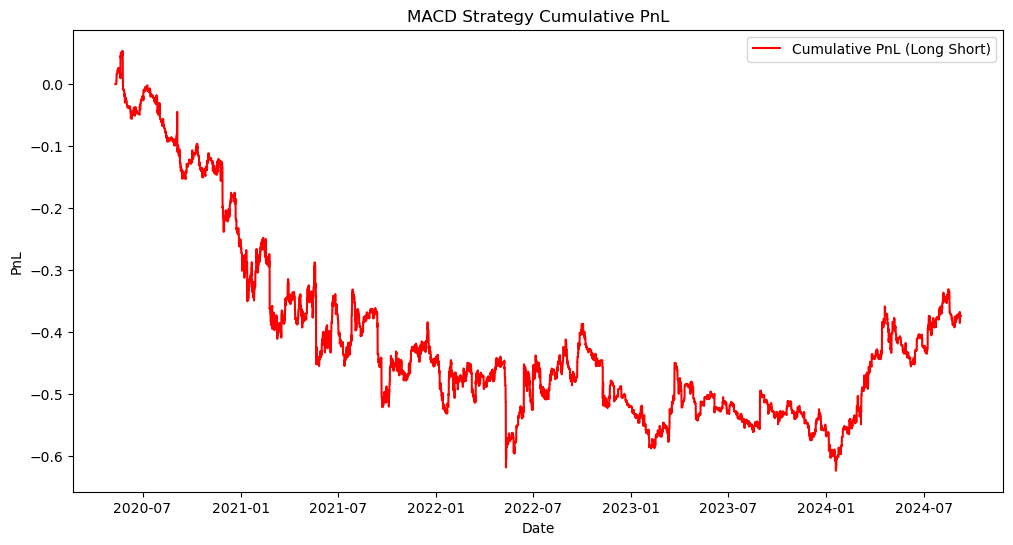

In [162]:
plt.figure(figsize=(12, 6))
plt.plot(macd_result['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('MACD Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

## Bayesian Optimization for MACD Strategy

In [164]:
# Define the search space for Bayesian optimization (MACD strategy)
space  = [Integer(5, 31, name='fast_length'),
          Integer(20, 51, name='slow_length')]

# Define the objective function to minimize (negative Sharpe Ratio)
@use_named_args(space)
def objective(**params):
    result = macd_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    if np.isnan(metrics['Sharpe Ratio']):
        return 0
    return -metrics['Sharpe Ratio']

# Perform Bayesian optimization
res = gp_minimize(objective, space, n_calls=50, random_state=0)

# Get the best parameters and the corresponding metrics
macd_best_params = {dim.name: res.x[i] for i, dim in enumerate(space)}
macd_best_result = macd_strategy(data, **macd_best_params)
macd_best_metrics = performance_metrics(macd_best_result,timeframe)

print("Best Parameters:", macd_best_params)
print("Best Metrics:", macd_best_metrics)


Best Parameters: {'fast_length': 20, 'slow_length': 37}
Best Metrics: {'Sharpe Ratio': 0.862481505850817, 'Average Return': 15.609864753335314, 'Maximum Drawdown': 20.642952614454146, 'Calmar Ratio': 0.7561837225942826, 'Number of Trades': 2794}


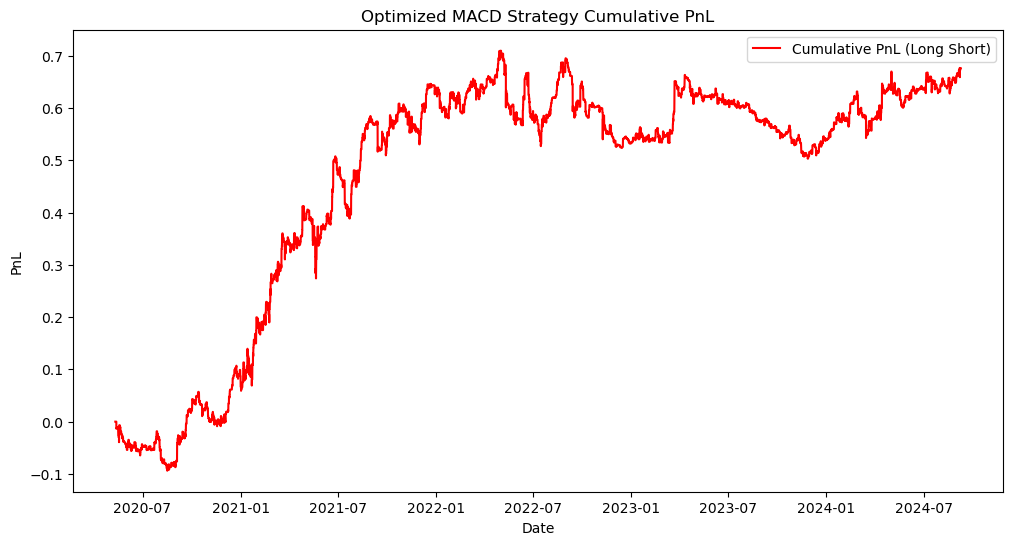

In [165]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(macd_best_result['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Optimized MACD Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

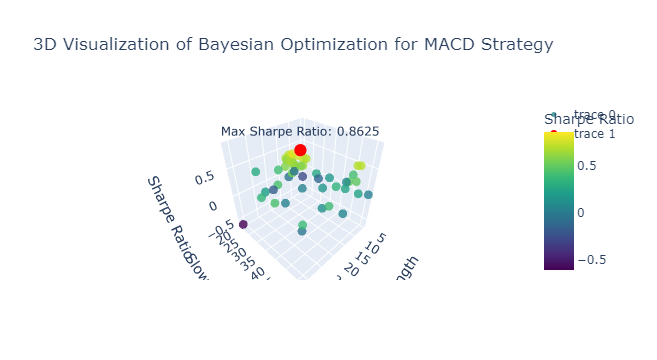

In [166]:
# Extract the evaluated points and corresponding negative Sharpe Ratios
x_vals = [point[0] for point in res.x_iters]
y_vals = [point[1] for point in res.x_iters]
z_vals = res.func_vals

# Convert negative Sharpe Ratios to positive for visualization
sharpe_ratios = [-z for z in z_vals]

# Find the highest Sharpe Ratio and its corresponding parameters
max_sharpe_ratio = max(sharpe_ratios)
max_index = sharpe_ratios.index(max_sharpe_ratio)
best_fast_length = x_vals[max_index]
best_slow_length = y_vals[max_index]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_vals,
    y=y_vals,
    z=sharpe_ratios,
    mode='markers',
    marker=dict(
        size=5,
        color=sharpe_ratios, # Color by Sharpe Ratio
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Sharpe Ratio')
    ),
    text=[f'Fast Length: {x}, Slow Length: {y}, Sharpe Ratio: {z:.4f}' for x, y, z in zip(x_vals, y_vals, sharpe_ratios)], 
    hoverinfo='text'
)])

# Highlight the highest Sharpe Ratio point
fig.add_trace(go.Scatter3d(
    x=[best_fast_length],
    y=[best_slow_length],
    z=[max_sharpe_ratio],
    mode='markers+text',
    marker=dict(
        size=7,
        color='red'
    ),
    text=[f'Max Sharpe Ratio: {max_sharpe_ratio:.4f}'],
    textposition='top center'
))

# Set labels and title
fig.update_layout(
    scene=dict(
        xaxis_title='Fast Length',
        yaxis_title='Slow Length',
        zaxis_title='Sharpe Ratio'
    ),
    title='3D Visualization of Bayesian Optimization for MACD Strategy',
    autosize=True
)

fig.show()


## Grid Search CV Optimization for MACD strategy

In [168]:
from sklearn.model_selection import ParameterGrid

# Define parameter grid for Grid Search
param_grid = {
    'fast_length': list(range(5, 31, 5)), 
    'slow_length': list(np.arange(20, 51, 5))  
}


# Run Grid Search
results = []
for params in ParameterGrid(param_grid):
    result = macd_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    sharpe_ratio = metrics['Sharpe Ratio']
    if not np.isnan(sharpe_ratio):
        results.append((params, sharpe_ratio))
    else:
        print(f"Skipping params {params} due to NaN Sharpe Ratio")

Skipping params {'fast_length': 20, 'slow_length': 20} due to NaN Sharpe Ratio
Skipping params {'fast_length': 25, 'slow_length': 25} due to NaN Sharpe Ratio
Skipping params {'fast_length': 30, 'slow_length': 30} due to NaN Sharpe Ratio


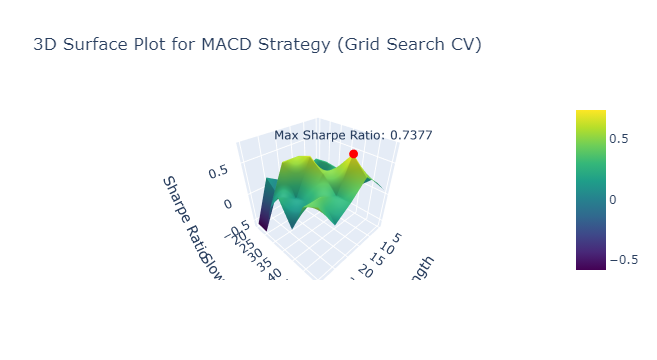

Best Parameters: {'fast_length': 15, 'slow_length': 45}
Best Sharpe Ratio: 0.7377361459663125
Average Return: 13.349513754966056
Maximum Drawdown: 19.224691592780225
Calmar Ratio: 0.6943941696302387
Number of Trades: 3020


In [169]:
# Ensure results were populated
if not results:
    print("No valid results found. Check strategy implementation and data.")
else:
    # Extract parameter values and Sharpe Ratios
    x_vals = [params['fast_length'] for params, _ in results]
    y_vals = [params['slow_length'] for params, _ in results]
    z_vals = [sharpe for _, sharpe in results]

    # Create grid for surface plot
    x_grid, y_grid = np.meshgrid(np.unique(x_vals), np.unique(y_vals))
    z_grid = np.zeros_like(x_grid, dtype=float)

    # Populate the z values based on the unique x and y values
    for i, x in enumerate(np.unique(x_vals)):
        for j, y in enumerate(np.unique(y_vals)):
            sharpe_values = [z for (xi, yi), z in zip(zip(x_vals, y_vals), z_vals) if xi == x and yi == y]
            if sharpe_values:
                z_grid[j, i] = max(sharpe_values)

    # Find the highest Sharpe Ratio
    max_sharpe_idx = np.unravel_index(np.argmax(z_grid, axis=None), z_grid.shape)
    max_sharpe_value = z_grid[max_sharpe_idx]
    best_fast_length = x_grid[max_sharpe_idx]
    best_slow_length = y_grid[max_sharpe_idx]

    # Plotly 3D surface plot
    fig = go.Figure(data=[go.Surface(x=x_grid, y=y_grid, z=z_grid, colorscale='Viridis')])

    # Add a scatter point for the maximum Sharpe Ratio
    fig.add_trace(go.Scatter3d(
        x=[best_fast_length],
        y=[best_slow_length],
        z=[max_sharpe_value],
        mode='markers+text',
        marker=dict(size=5, color='red'),
        text=[f'Max Sharpe Ratio: {max_sharpe_value:.4f}'],
        textposition='top center'
    ))

    fig.update_layout(title='3D Surface Plot for MACD Strategy (Grid Search CV)', scene=dict(
        xaxis_title='Fast Length',
        yaxis_title='Slow Length',
        zaxis_title='Sharpe Ratio'
    ))
    fig.show()

    # Print the best parameters and metrics
    print("Best Parameters:", {"fast_length": best_fast_length, "slow_length": best_slow_length})
    print("Best Sharpe Ratio:", max_sharpe_value)
    best_result = macd_strategy(data.copy(), fast_length=best_fast_length, slow_length=best_slow_length)
    best_metrics = performance_metrics(best_result,timeframe)
    print("Average Return:", best_metrics.get('Average Return', 'N/A'))
    print("Maximum Drawdown:", best_metrics.get('Maximum Drawdown', 'N/A'))
    print("Calmar Ratio:", best_metrics.get('Calmar Ratio', 'N/A'))
    print("Number of Trades:", best_metrics.get('Number of Trades', 'N/A'))

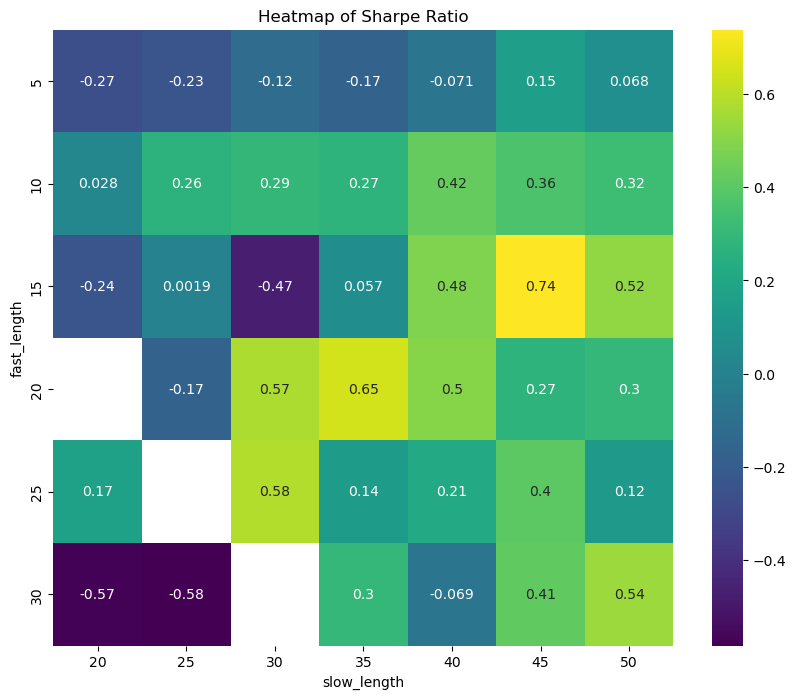

In [170]:
plot_heatmap(results, 'fast_length', 'slow_length', 'Sharpe Ratio')

## 2. Moving Average 2 Line Cross Strategy

In [172]:
def moving_avg_cross_strategy(data, fast_length=9, slow_length=18):
    """
    Apply the Moving Average Cross strategy on a given DataFrame.
    
    Parameters:
    - data (pd.DataFrame): DataFrame with a 'Close' price column.
    - fast_length (int): Fast moving average window length.
    - slow_length (int): Slow moving average window length.
    
    Returns:
    - data (pd.DataFrame): DataFrame with MA strategy columns and cumulative returns.
    """
    # Calculate fast and slow moving averages
    data['fast_ma'] = ta.trend.SMAIndicator(close=data['Close'], window=fast_length).sma_indicator()
    data['slow_ma'] = ta.trend.SMAIndicator(close=data['Close'], window=slow_length).sma_indicator()
    
    # Generate trading signals
    data['long_signal'] = (data['fast_ma'] > data['slow_ma']) & (data['fast_ma'].shift(1) <= data['slow_ma'].shift(1))
    data['short_signal'] = (data['fast_ma'] < data['slow_ma']) & (data['fast_ma'].shift(1) >= data['slow_ma'].shift(1))
    
    # Initialize positions
    data['Position (Long Short)'] = 0
    data.loc[data['long_signal'], 'Position (Long Short)'] = 1
    data.loc[data['short_signal'], 'Position (Long Short)'] = -1
    
    # Forward fill positions
    data['Position (Long Short)'] = data['Position (Long Short)'].replace(0, pd.NA).ffill().fillna(0)
    
    # Define trading fees
    taker_fee = 0.00055  # 0.055%

    # Calculate strategy returns with fees
    data['PnL (Long Short)'] = data['Position (Long Short)'].shift(1) * data['Close'].pct_change()
    data['PnL (Long Short) with Fees'] = data['PnL (Long Short)'] - (abs(data['Position (Long Short)'].shift(1) - data['Position (Long Short)']) * taker_fee)

    # Calculate cumulative returns
    data['Cumulative PnL (Long Short)'] = data['PnL (Long Short) with Fees'].cumsum()
    
    # Calculate drawdown
    data['Cumulative Max'] = data['Cumulative PnL (Long Short)'].cummax()
    data['Drawdown (Long Short)'] = data['Cumulative Max'] - data['Cumulative PnL (Long Short)']
    
    # Calculate number of trades
    data['Trade Entry'] = (data['Position (Long Short)'] != 0) & (data['Position (Long Short)'] != data['Position (Long Short)'].shift(1))
    data['Number of Trades'] = data['Trade Entry'].cumsum()
    
    return data


In [173]:
# Run the strategy
ma_cross2_data = moving_avg_cross_strategy(data)

# Calculate performance metrics
metrics = performance_metrics(ma_cross2_data,timeframe)
print(metrics)

{'Sharpe Ratio': 0.6269050931862864, 'Average Return': 39.44661987303545, 'Maximum Drawdown': 192.76437414401664, 'Calmar Ratio': 0.2046364638082159, 'Number of Trades': 2465}


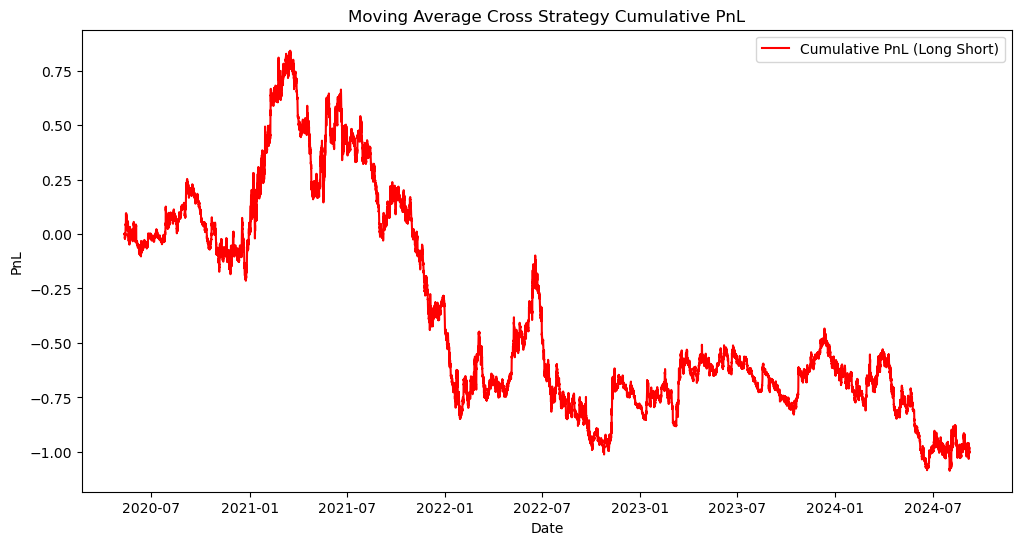

In [174]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(ma_cross2_data['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Moving Average Cross Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

In [175]:
# Define the search space for Bayesian optimization (Moving Average Cross strategy)
space  = [Integer(5, 21, name='fast_length'),
          Integer(20, 51, name='slow_length')]

# Define the objective function to minimize (negative Sharpe Ratio)
@use_named_args(space)
def objective(**params):
    result = moving_avg_cross_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    if np.isnan(metrics['Sharpe Ratio']):
        return 0
    return -metrics['Sharpe Ratio']

# Perform Bayesian optimization
res = gp_minimize(objective, space, n_calls=50, random_state=0)

# Get the best parameters and the corresponding metrics
ma_cross_best_params = {dim.name: res.x[i] for i, dim in enumerate(space)}
ma_cross_best_result = moving_avg_cross_strategy(data, **ma_cross_best_params)
ma_cross_best_metrics = performance_metrics(ma_cross_best_result,timeframe)

print("Best Parameters:", ma_cross_best_params)
print("Best Metrics:", ma_cross_best_metrics)


Best Parameters: {'fast_length': 12, 'slow_length': 23}
Best Metrics: {'Sharpe Ratio': 0.9140312697466908, 'Average Return': 57.51155842901766, 'Maximum Drawdown': 155.19060035065135, 'Calmar Ratio': 0.3705866096211431, 'Number of Trades': 1933}


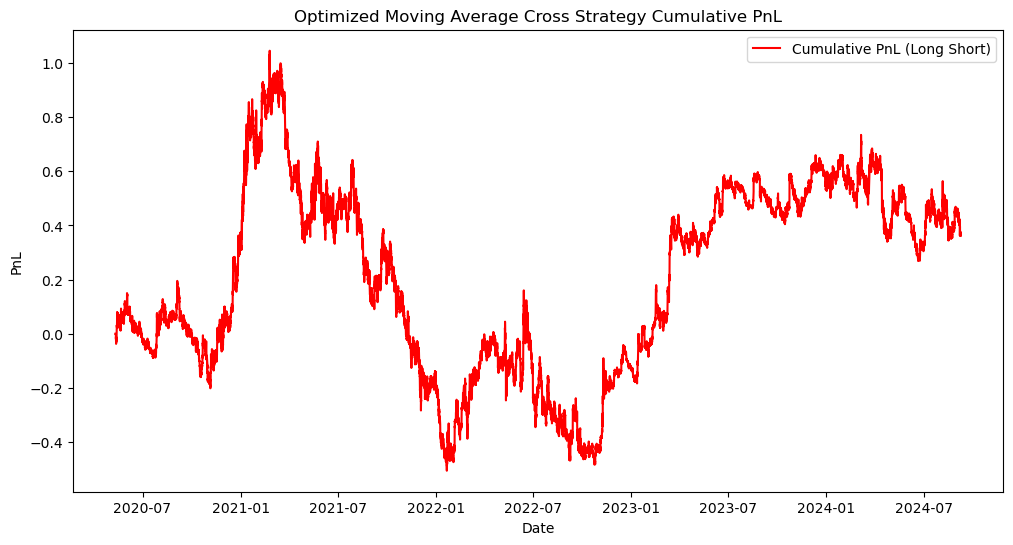

In [176]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(ma_cross_best_result['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Optimized Moving Average Cross Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

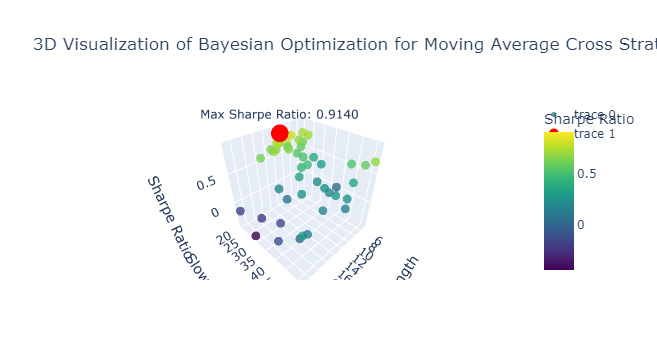

In [177]:
# Extract the evaluated points and corresponding negative Sharpe Ratios
x_vals = [point[0] for point in res.x_iters]
y_vals = [point[1] for point in res.x_iters]
z_vals = res.func_vals

# Convert negative Sharpe Ratios to positive for visualization
sharpe_ratios = [-z for z in z_vals]

# Find the highest Sharpe Ratio and its corresponding parameters
max_sharpe_ratio = max(sharpe_ratios)
max_index = sharpe_ratios.index(max_sharpe_ratio)
best_fast_length = x_vals[max_index]
best_slow_length = y_vals[max_index]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_vals,
    y=y_vals,
    z=sharpe_ratios,
    mode='markers',
    marker=dict(
        size=5,
        color=sharpe_ratios, 
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Sharpe Ratio')
    ),
    text=[f'Fast Length: {x}, Slow Length: {y}, Sharpe Ratio: {z:.4f}' for x, y, z in zip(x_vals, y_vals, sharpe_ratios)], # Hover text
    hoverinfo='text'
)])

# Highlight the highest Sharpe Ratio point
fig.add_trace(go.Scatter3d(
    x=[best_fast_length],
    y=[best_slow_length],
    z=[max_sharpe_ratio],
    mode='markers+text',
    marker=dict(
        size=10,
        color='red'
    ),
    text=[f'Max Sharpe Ratio: {max_sharpe_ratio:.4f}'],
    textposition='top center'
))

# Set labels and title
fig.update_layout(
    scene=dict(
        xaxis_title='Fast Length',
        yaxis_title='Slow Length',
        zaxis_title='Sharpe Ratio'
    ),
    title='3D Visualization of Bayesian Optimization for Moving Average Cross Strategy',
    autosize=True
)

fig.show()

## Permutation Testing(Grid Search CV)

In [179]:
# Define parameter grid for Grid Search
param_grid = {
    'fast_length': list(range(5, 21, 5)), 
    'slow_length': list(np.arange(20, 51, 5))  
}


# Run Grid Search
results = []
for params in ParameterGrid(param_grid):
    result = moving_avg_cross_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    sharpe_ratio = metrics['Sharpe Ratio']
    if not np.isnan(sharpe_ratio):
        results.append((params, sharpe_ratio))
    else:
        print(f"Skipping params {params} due to NaN Sharpe Ratio")

Skipping params {'fast_length': 20, 'slow_length': 20} due to NaN Sharpe Ratio


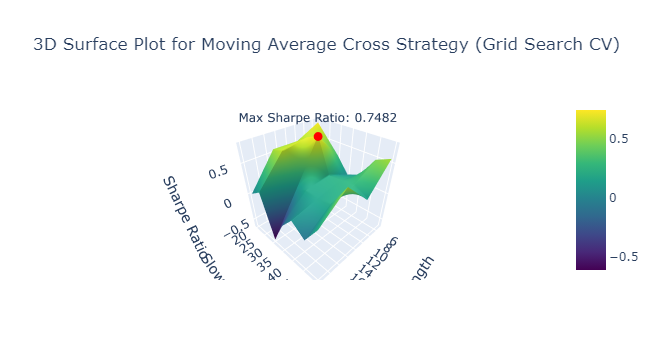

Best Parameters: {'fast_length': 10, 'slow_length': 30}
Best Sharpe Ratio: 0.7481930302786557
Average Return: 47.073373382805904
Maximum Drawdown: 124.49741646215115
Calmar Ratio: 0.37810723082046305
Number of Trades: 1546


In [180]:
# Ensure results were populated
if not results:
    print("No valid results found. Check strategy implementation and data.")
else:
    # Extract parameter values and Sharpe Ratios
    x_vals = [params['fast_length'] for params, _ in results]
    y_vals = [params['slow_length'] for params, _ in results]
    z_vals = [sharpe for _, sharpe in results]

    # Create grid for surface plot
    x_grid, y_grid = np.meshgrid(np.unique(x_vals), np.unique(y_vals))
    z_grid = np.zeros_like(x_grid, dtype=float)

    # Populate the z values based on the unique x and y values
    for i, x in enumerate(np.unique(x_vals)):
        for j, y in enumerate(np.unique(y_vals)):
            sharpe_values = [z for (xi, yi), z in zip(zip(x_vals, y_vals), z_vals) if xi == x and yi == y]
            if sharpe_values:
                z_grid[j, i] = max(sharpe_values)

    # Find the highest Sharpe Ratio
    max_sharpe_idx = np.unravel_index(np.argmax(z_grid, axis=None), z_grid.shape)
    max_sharpe_value = z_grid[max_sharpe_idx]
    best_fast_length = x_grid[max_sharpe_idx]
    best_slow_length = y_grid[max_sharpe_idx]

    # Plotly 3D surface plot
    fig = go.Figure(data=[go.Surface(x=x_grid, y=y_grid, z=z_grid, colorscale='Viridis')])

    # Add a scatter point for the maximum Sharpe Ratio
    fig.add_trace(go.Scatter3d(
        x=[best_fast_length],
        y=[best_slow_length],
        z=[max_sharpe_value],
        mode='markers+text',
        marker=dict(size=5, color='red'),
        text=[f'Max Sharpe Ratio: {max_sharpe_value:.4f}'],
        textposition='top center'
    ))

    fig.update_layout(title='3D Surface Plot for Moving Average Cross Strategy (Grid Search CV)', scene=dict(
        xaxis_title='Fast Length',
        yaxis_title='Slow Length',
        zaxis_title='Sharpe Ratio'
    ))
    fig.show()

    # Print the best parameters and metrics
    print("Best Parameters:", {"fast_length": best_fast_length, "slow_length": best_slow_length})
    print("Best Sharpe Ratio:", max_sharpe_value)
    best_result = moving_avg_cross_strategy(data.copy(), fast_length=best_fast_length, slow_length=best_slow_length)
    best_metrics = performance_metrics(best_result,timeframe)
    print("Average Return:", best_metrics.get('Average Return', 'N/A'))
    print("Maximum Drawdown:", best_metrics.get('Maximum Drawdown', 'N/A'))
    print("Calmar Ratio:", best_metrics.get('Calmar Ratio', 'N/A'))
    print("Number of Trades:", best_metrics.get('Number of Trades', 'N/A'))

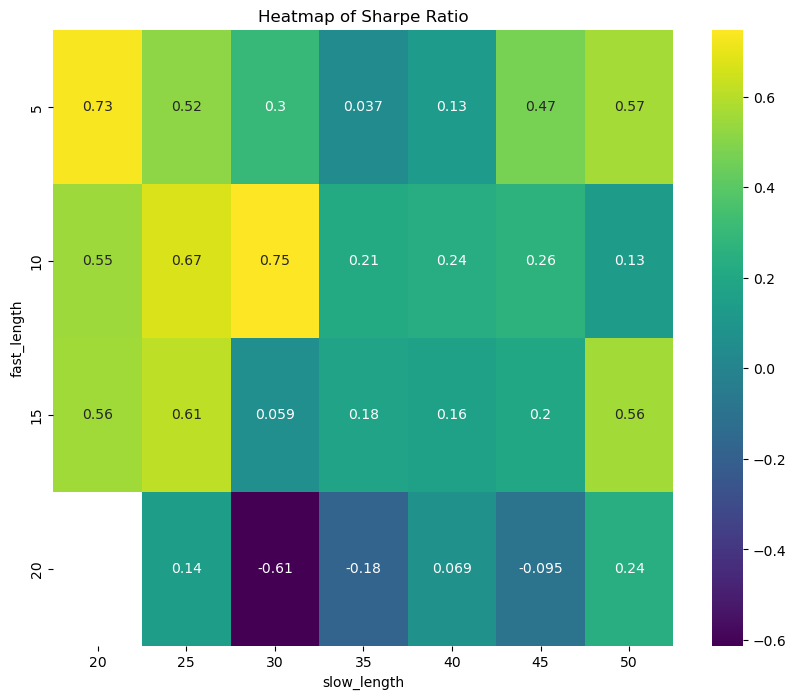

In [181]:
plot_heatmap(results, 'fast_length', 'slow_length', 'Sharpe Ratio')

## 3.ADX DI Crossover Strategy(Momentum BreakOut)

In [183]:
def adx_di_crossover_strategy(data, adx_length=14, adx_threshold=25):
    """
    Apply ADX and DI Crossover Strategy on a given DataFrame.
    
    Parameters:
    - data (pd.DataFrame): DataFrame with 'High', 'Low', 'Close' price columns.
    - adx_length (int): Length for ADX calculation.
    - adx_threshold (int): Threshold for ADX to consider a strong trend.
    
    Returns:
    - data (pd.DataFrame): DataFrame with strategy results.
    """
    # Calculate ADX, +DI, -DI
    adx = ta.trend.ADXIndicator(data['High'], data['Low'], data['Close'], window=adx_length)
    data['adx'] = adx.adx()
    data['+DI'] = adx.adx_pos()
    data['-DI'] = adx.adx_neg()
    
    # Generate signals
    data['long_signal'] = (data['adx'] > adx_threshold) & (data['+DI'] > data['-DI']) & (data['+DI'].shift(1) <= data['-DI'].shift(1))
    data['short_signal'] = (data['adx'] > adx_threshold) & (data['-DI'] > data['+DI']) & (data['-DI'].shift(1) <= data['+DI'].shift(1))
    
    # Initialize positions
    data['Position (Long Short)'] = 0
    data.loc[data['long_signal'], 'Position (Long Short)'] = 1
    data.loc[data['short_signal'], 'Position (Long Short)'] = -1
    data['Position (Long Short)'] = data['Position (Long Short)'].replace(0, pd.NA).ffill().fillna(0)
    
    # Define trading fees
    taker_fee = 0.00055  # 0.055%

    # Calculate strategy returns with fees
    data['PnL (Long Short)'] = data['Position (Long Short)'].shift(1) * data['Close'].pct_change()
    data['PnL (Long Short) with Fees'] = data['PnL (Long Short)'] - (abs(data['Position (Long Short)'].shift(1) - data['Position (Long Short)']) * taker_fee)

    # Calculate cumulative returns
    data['Cumulative PnL (Long Short)'] = data['PnL (Long Short) with Fees'].cumsum()
    
    # Calculate drawdown
    data['Cumulative Max'] = data['Cumulative PnL (Long Short)'].cummax()
    data['Drawdown (Long Short)'] = data['Cumulative Max'] - data['Cumulative PnL (Long Short)']
    
    # Calculate number of trades
    data['Trade Entry'] = (data['Position (Long Short)'] != 0) & (data['Position (Long Short)'] != data['Position (Long Short)'].shift(1))
    data['Number of Trades'] = data['Trade Entry'].cumsum()
    
    return data


In [184]:
# Run the strategy
adx_di_data = adx_di_crossover_strategy(data)

# Calculate and print performance metrics
metrics = performance_metrics(adx_di_data,timeframe)
print(metrics)

{'Sharpe Ratio': -0.29825177951135673, 'Average Return': -18.745051102917504, 'Maximum Drawdown': 212.6374440716787, 'Calmar Ratio': -0.08815498692976516, 'Number of Trades': 460}


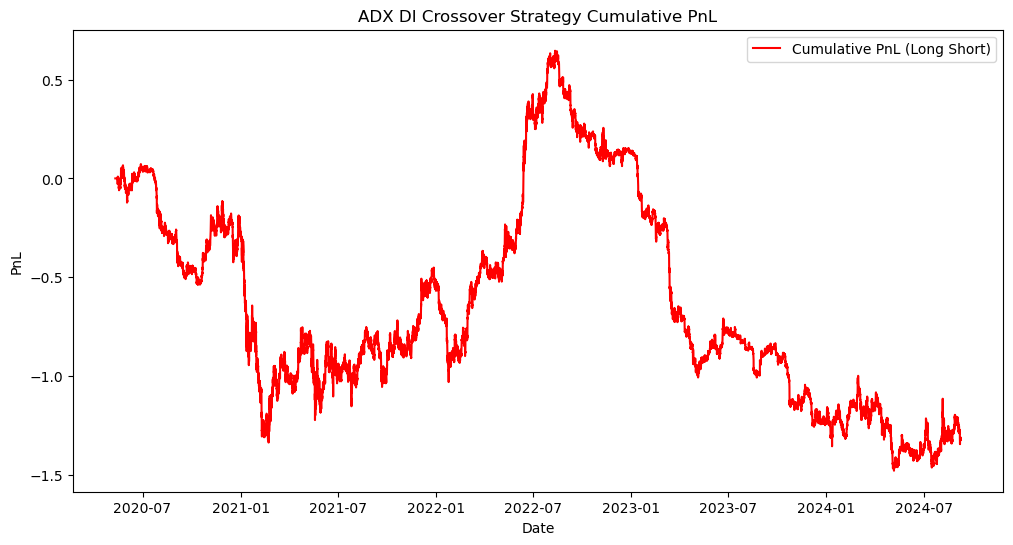

In [185]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(adx_di_data ['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('ADX DI Crossover Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

In [186]:
# Define the search space for Bayesian optimization (ADX DI Crossover strategy)
space  = [Integer(5, 51, name='adx_length'),
          Integer(10, 51, name='adx_threshold')]

# Define the objective function to minimize (negative Sharpe Ratio)
@use_named_args(space)
def objective(**params):
    result = adx_di_crossover_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    if np.isnan(metrics['Sharpe Ratio']):
        return 0
    return -metrics['Sharpe Ratio']
    
# Perform Bayesian optimization
res = gp_minimize(objective, space, n_calls=50, random_state=0)

# Get the best parameters and the corresponding metrics
adx_best_params = {dim.name: res.x[i] for i, dim in enumerate(space)}
adx_best_result = adx_di_crossover_strategy(data, **adx_best_params)
adx_best_metrics = performance_metrics(adx_best_result,timeframe)

print("Best Parameters:", adx_best_params)
print("Best Metrics:", adx_best_metrics)

Best Parameters: {'adx_length': 51, 'adx_threshold': 12}
Best Metrics: {'Sharpe Ratio': 1.063215342802071, 'Average Return': 66.80487027997111, 'Maximum Drawdown': 77.47438714381994, 'Calmar Ratio': 0.8622833008792645, 'Number of Trades': 511}


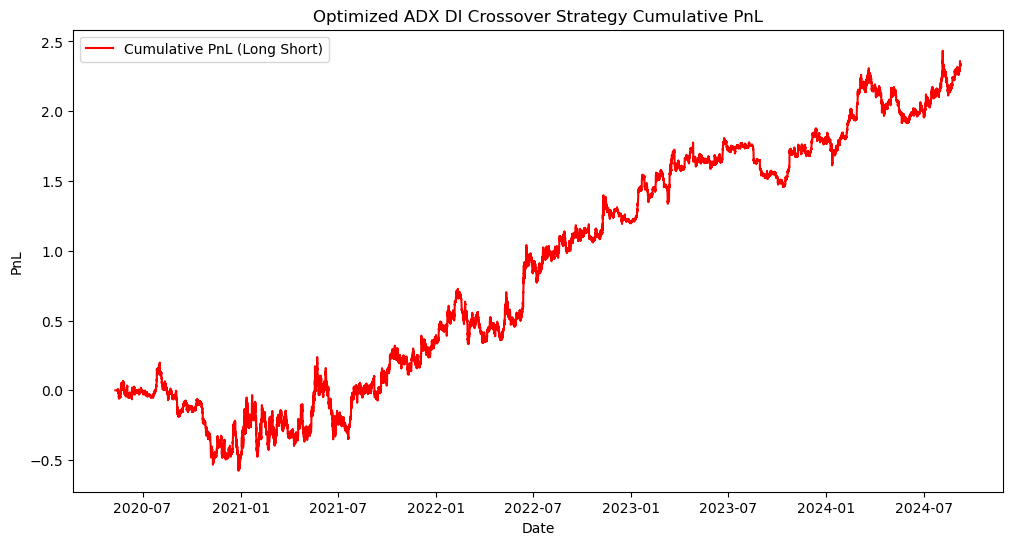

In [187]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(adx_best_result ['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Optimized ADX DI Crossover Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

## Bayesian Optimization

In [189]:
# Extract the evaluated points and corresponding negative Sharpe Ratios
x_vals = [point[0] for point in res.x_iters]
y_vals = [point[1] for point in res.x_iters]
z_vals = res.func_vals

# Convert negative Sharpe Ratios to positive for visualization
sharpe_ratios = [-z for z in z_vals]

# Find the highest Sharpe Ratio and its corresponding parameters
max_sharpe_ratio = max(sharpe_ratios)
max_index = sharpe_ratios.index(max_sharpe_ratio)
best_adx_length = x_vals[max_index]
best_adx_threshold = y_vals[max_index]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_vals,
    y=y_vals,
    z=sharpe_ratios,
    mode='markers',
    marker=dict(
        size=5,
        color=sharpe_ratios, 
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Sharpe Ratio')
    ),
    text=[f'ADX Length: {x}, ADX Threshold: {y}, Sharpe Ratio: {z:.4f}' for x, y, z in zip(x_vals, y_vals, sharpe_ratios)], # Hover text
    hoverinfo='text'
)])

# Highlight the highest Sharpe Ratio point
fig.add_trace(go.Scatter3d(
    x=[best_adx_length],
    y=[best_adx_threshold],
    z=[max_sharpe_ratio],
    mode='markers+text',
    marker=dict(
        size=10,
        color='red'
    ),
    text=[f'Max Sharpe Ratio: {max_sharpe_ratio:.4f}'],
    textposition='top center'
))

# Set labels and title
fig.update_layout(
    scene=dict(
        xaxis_title='ADX Length',
        yaxis_title='ADX Threshold',
        zaxis_title='Sharpe Ratio'
    ),
    title='3D Visualization of Bayesian Optimization for ADX DI Crossover Strategy',
    autosize=True
)

fig.show()


## Permutation Testing(Grid Search CV)

In [191]:
# Define parameter grid for Grid Search
param_grid = {
    'adx_length': list(range(5, 51, 5)), 
    'adx_threshold': list(np.arange(10, 51, 5))  
}


# Run Grid Search
results = []
for params in ParameterGrid(param_grid):
    result = adx_di_crossover_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    sharpe_ratio = metrics['Sharpe Ratio']
    if not np.isnan(sharpe_ratio):
        results.append((params, sharpe_ratio))
    else:
        print(f"Skipping params {params} due to NaN Sharpe Ratio")

Skipping params {'adx_length': 25, 'adx_threshold': 50} due to NaN Sharpe Ratio
Skipping params {'adx_length': 30, 'adx_threshold': 40} due to NaN Sharpe Ratio
Skipping params {'adx_length': 30, 'adx_threshold': 45} due to NaN Sharpe Ratio
Skipping params {'adx_length': 30, 'adx_threshold': 50} due to NaN Sharpe Ratio
Skipping params {'adx_length': 35, 'adx_threshold': 40} due to NaN Sharpe Ratio
Skipping params {'adx_length': 35, 'adx_threshold': 45} due to NaN Sharpe Ratio
Skipping params {'adx_length': 35, 'adx_threshold': 50} due to NaN Sharpe Ratio
Skipping params {'adx_length': 40, 'adx_threshold': 35} due to NaN Sharpe Ratio
Skipping params {'adx_length': 40, 'adx_threshold': 40} due to NaN Sharpe Ratio
Skipping params {'adx_length': 40, 'adx_threshold': 45} due to NaN Sharpe Ratio
Skipping params {'adx_length': 40, 'adx_threshold': 50} due to NaN Sharpe Ratio
Skipping params {'adx_length': 45, 'adx_threshold': 35} due to NaN Sharpe Ratio
Skipping params {'adx_length': 45, 'adx_

In [192]:
# Ensure results were populated
if not results:
    print("No valid results found. Check strategy implementation and data.")
else:
    # Extract parameter values and Sharpe Ratios
    x_vals = [params['adx_length'] for params, _ in results]
    y_vals = [params['adx_threshold'] for params, _ in results]
    z_vals = [sharpe for _, sharpe in results]

    # Create grid for surface plot
    x_grid, y_grid = np.meshgrid(np.unique(x_vals), np.unique(y_vals))
    z_grid = np.zeros_like(x_grid, dtype=float)

    # Populate the z values based on the unique x and y values
    for i, x in enumerate(np.unique(x_vals)):
        for j, y in enumerate(np.unique(y_vals)):
            sharpe_values = [z for (xi, yi), z in zip(zip(x_vals, y_vals), z_vals) if xi == x and yi == y]
            if sharpe_values:
                z_grid[j, i] = max(sharpe_values)

    # Find the highest Sharpe Ratio
    max_sharpe_idx = np.unravel_index(np.argmax(z_grid, axis=None), z_grid.shape)
    max_sharpe_value = z_grid[max_sharpe_idx]
    best_adx_length = x_grid[max_sharpe_idx]
    best_adx_threshold = y_grid[max_sharpe_idx]

    # Plotly 3D surface plot
    fig = go.Figure(data=[go.Surface(x=x_grid, y=y_grid, z=z_grid, colorscale='Viridis')])

    # Add a scatter point for the maximum Sharpe Ratio
    fig.add_trace(go.Scatter3d(
        x=[best_adx_length],
        y=[best_adx_threshold],
        z=[max_sharpe_value],
        mode='markers+text',
        marker=dict(size=5, color='red'),
        text=[f'Max Sharpe Ratio: {max_sharpe_value:.4f}'],
        textposition='top center'
    ))

    fig.update_layout(title='3D Surface Plot for ADX DI Crossover Strategy (Grid Search CV)', scene=dict(
        xaxis_title='ADX Length',
        yaxis_title='ADX Threshold',
        zaxis_title='Sharpe Ratio'
    ))
    fig.show()

# Print the best parameters and metrics
    print("Best Parameters:", {"adx_length": best_adx_length, "adx_threshold": best_adx_threshold})
    print("Best Sharpe Ratio:", max_sharpe_value)
    best_result = adx_di_crossover_strategy(data.copy(), adx_length=best_adx_length, adx_threshold=best_adx_threshold)
    best_metrics = performance_metrics(best_result,timeframe)
    print("Average Return:", best_metrics.get('Average Return', 'N/A'))
    print("Maximum Drawdown:", best_metrics.get('Maximum Drawdown', 'N/A'))
    print("Calmar Ratio:", best_metrics.get('Calmar Ratio', 'N/A'))
    print("Number of Trades:", best_metrics.get('Number of Trades', 'N/A'))

Best Parameters: {'adx_length': 15, 'adx_threshold': 40}
Best Sharpe Ratio: 1.9098796527761766
Average Return: 120.01109244690437
Maximum Drawdown: 68.3514830335195
Calmar Ratio: 1.7557935412762158
Number of Trades: 31


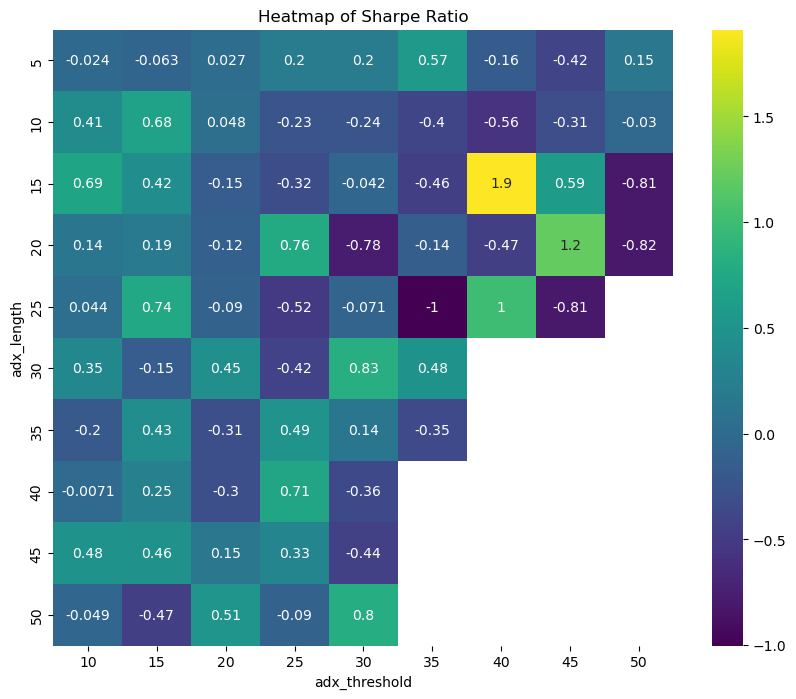

In [193]:
plot_heatmap(results, 'adx_length', 'adx_threshold', 'Sharpe Ratio')

## Ranging Strategy

## 1. Mean Reversion

In [196]:
def mean_reversion_strategy(data, move_limit=10, ma_length=50):
    """
    Apply the Mean Reversion Strategy on a given DataFrame.
    
    Parameters:
    - data (pd.DataFrame): DataFrame with 'Open', 'High', 'Low', and 'Close' columns.
    - move_limit (int): Percentage limit to identify a big move.
    - ma_length (int): Moving average period length.
    
    Returns:
    - data (pd.DataFrame): DataFrame with strategy columns and cumulative returns.
    """
    # Moving Average
    data['ma'] = ta.trend.SMAIndicator(data['Close'], window=ma_length).sma_indicator()
    
    # Identify Down and Up Bars
    data['down_bar'] = data['Open'] > data['Close']
    data['up_bar'] = ~data['down_bar']
    
    # Identify 2 consecutive down/up bars
    data['is_two_down'] = data['down_bar'] & data['down_bar'].shift(1)
    data['is_two_up'] = data['up_bar'] & data['up_bar'].shift(1)
    
    # Identify Big Moves
    data['big_move_down'] = ((data['Open'] - data['Close']) / (0.001 + data['High'] - data['Low'])) > move_limit / 100.0
    data['big_move_up'] = ((data['Close'] - data['Open']) / (0.001 + data['High'] - data['Low'])) > move_limit / 100.0
    
    # Long Entry and Exit Signals
    data['is_long_buy'] = data['is_two_down'] & data['big_move_down']
    data['is_long_exit'] = data['Close'] > data['High'].shift(1)
    
    # Short Entry and Exit Signals
    data['is_short_buy'] = data['is_two_up'] & data['big_move_up'] & (data['Close'] < data['ma'])
    data['is_short_exit'] = data['Close'] < data['Low'].shift(1)
    
    # Initialize Positions
    data['Position (Long Short)'] = 0
    data.loc[data['is_long_buy'], 'Position (Long Short)'] = 1
    data.loc[data['is_long_exit'], 'Position (Long Short)'] = 0
    data.loc[data['is_short_buy'], 'Position (Long Short)'] = -1
    data.loc[data['is_short_exit'], 'Position (Long Short)'] = 0
    data['Position (Long Short)'] = data['Position (Long Short)'].replace(0, pd.NA).ffill().fillna(0).infer_objects(copy=False)
    
    # Define trading fees
    taker_fee = 0.00055  # 0.055%

    # Calculate PnL with fees
    data['PnL (Long Short)'] = data['Position (Long Short)'].shift(1) * (data['Close'] / data['Close'].shift(1) - 1)
    data['PnL (Long Short) with Fees'] = data['PnL (Long Short)'] - (abs(data['Position (Long Short)'].shift(1) - data['Position (Long Short)']) * taker_fee)

    # Calculate Cumulative PnL
    data['Cumulative PnL (Long Short)'] = data['PnL (Long Short) with Fees'].cumsum()
    
    # Calculate Cumulative Max and Drawdown
    data['Cumulative Max'] = data['Cumulative PnL (Long Short)'].cummax()
    data['Drawdown (Long Short)'] = data['Cumulative Max'] - data['Cumulative PnL (Long Short)']

    # Calculate Number of Trades
    data['Number of Trades'] = ((data['Position (Long Short)'] != 0) & (data['Position (Long Short)'] != data['Position (Long Short)'].shift(1))).cumsum()
    
    return data


In [197]:
mean_reversion_data = mean_reversion_strategy(data)

# Calculate the performance metrics
metrics = performance_metrics(mean_reversion_data,timeframe)
print(metrics)

{'Sharpe Ratio': 0.8752981370286741, 'Average Return': 55.13403404738059, 'Maximum Drawdown': 189.46094528541175, 'Calmar Ratio': 0.2910047448793439, 'Number of Trades': 1860}


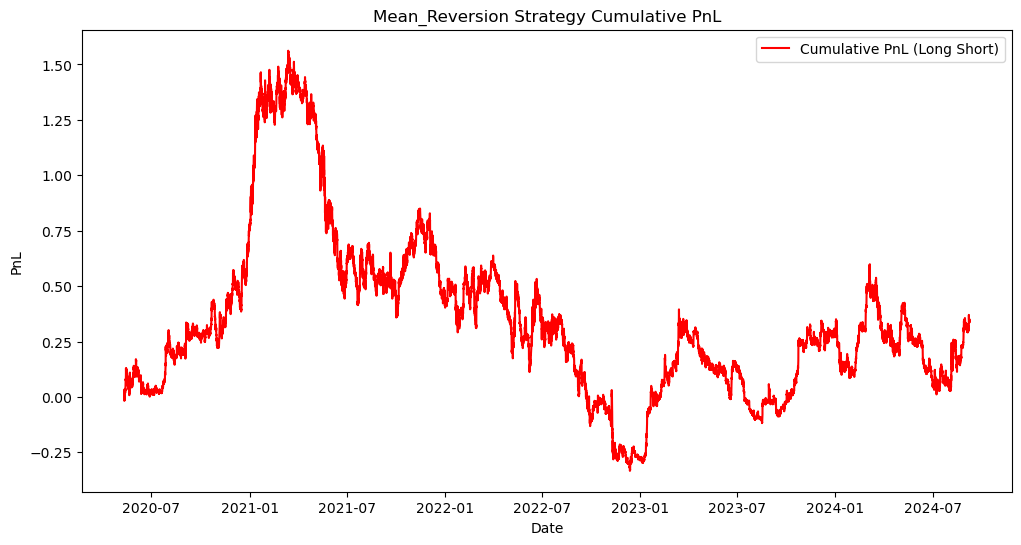

In [198]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(mean_reversion_data['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Mean_Reversion Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

## Bayesian Optimzation

In [200]:
# Define the search space for Bayesian optimization (Mean Reversion strategy)
space  = [Real(1, 21, name='move_limit'),
          Integer(10, 201, name='ma_length')]

# Define the objective function to minimize (negative Sharpe Ratio)
@use_named_args(space)
def objective(**params):
    result = mean_reversion_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    if np.isnan(metrics['Sharpe Ratio']):
        return 0
    return -metrics['Sharpe Ratio']

# Perform Bayesian optimization
res = gp_minimize(objective, space, n_calls=50, random_state=0)

# Get the best parameters and the corresponding metrics
mean_reversion_best_params = {dim.name: res.x[i] for i, dim in enumerate(space)}
mean_reversion_best_result = mean_reversion_strategy(data, **mean_reversion_best_params)
mean_reversion_best_metrics = performance_metrics(mean_reversion_best_result,timeframe)

print("Best Parameters:", mean_reversion_best_params)
print("Best Metrics:", mean_reversion_best_metrics)

Best Parameters: {'move_limit': 20.179126972351778, 'ma_length': 118}
Best Metrics: {'Sharpe Ratio': 1.3580560292336876, 'Average Return': 85.53714115025495, 'Maximum Drawdown': 95.33075950621517, 'Calmar Ratio': 0.8972669639192196, 'Number of Trades': 1392}


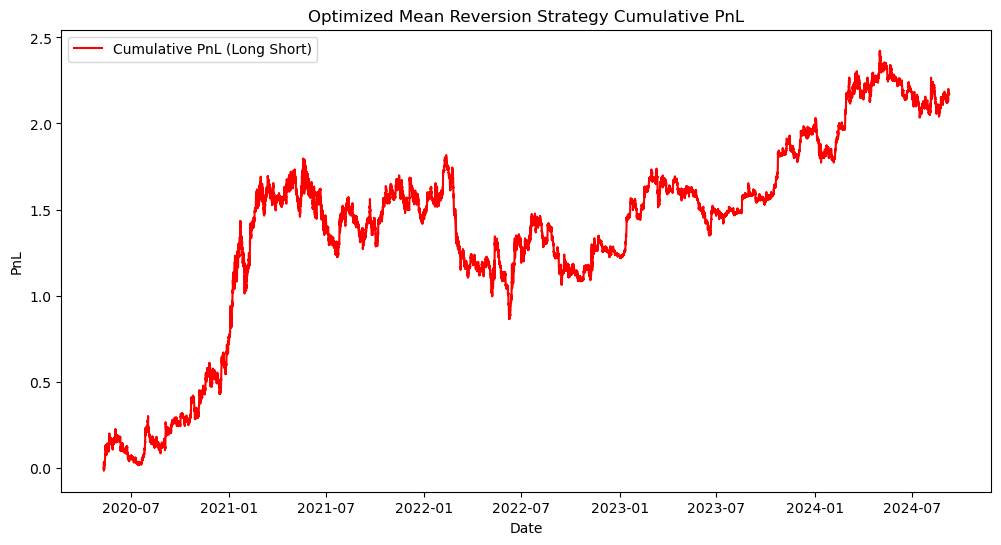

In [201]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(mean_reversion_best_result['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Optimized Mean Reversion Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

In [202]:
# Extract the evaluated points and corresponding negative Sharpe Ratios
x_vals = [point[0] for point in res.x_iters]
y_vals = [point[1] for point in res.x_iters]
z_vals = res.func_vals

# Convert negative Sharpe Ratios to positive for visualization
sharpe_ratios = [-z for z in z_vals]

# Find the highest Sharpe Ratio and its corresponding parameters
max_sharpe_ratio = max(sharpe_ratios)
max_index = sharpe_ratios.index(max_sharpe_ratio)
best_move_limit = x_vals[max_index]
best_ma_length = y_vals[max_index]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_vals,
    y=y_vals,
    z=sharpe_ratios,
    mode='markers',
    marker=dict(
        size=5,
        color=sharpe_ratios,  
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Sharpe Ratio')
    ),
    text=[f'Move Limit: {x}, MA Length: {y}, Sharpe Ratio: {z:.4f}' for x, y, z in zip(x_vals, y_vals, sharpe_ratios)],  # Hover text
    hoverinfo='text'
)])

# Highlight the highest Sharpe Ratio point
fig.add_trace(go.Scatter3d(
    x=[best_move_limit],
    y=[best_ma_length],
    z=[max_sharpe_ratio],
    mode='markers+text',
    marker=dict(
        size=10,
        color='red'
    ),
    text=[f'Max Sharpe Ratio: {max_sharpe_ratio:.4f}'],
    textposition='top center'
))

# Set labels and title
fig.update_layout(
    scene=dict(
        xaxis_title='Move Limit',
        yaxis_title='MA Length',
        zaxis_title='Sharpe Ratio'
    ),
    title='3D Visualization of Bayesian Optimization for Mean Reversion Strategy',
    autosize=True
)

fig.show()


## Permutation Testing(Grid Search CV)

In [204]:
# Define parameter grid for Grid Search
param_grid = {
    'move_limit': list(range(1, 21, 2)), 
    'ma_length': list(np.arange(10, 201, 20))  
}

# Run Grid Search
results = []
for params in ParameterGrid(param_grid):
    result = mean_reversion_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    sharpe_ratio = metrics['Sharpe Ratio']
    if not np.isnan(sharpe_ratio):
        results.append((params, sharpe_ratio))
    else:
        print(f"Skipping params {params} due to NaN Sharpe Ratio")

In [205]:
# Ensure results were populated
if not results:
    print("No valid results found. Check strategy implementation and data.")
else:
    # Extract parameter values and Sharpe Ratios
    x_vals = [params['move_limit'] for params, _ in results]
    y_vals = [params['ma_length'] for params, _ in results]
    z_vals = [sharpe for _, sharpe in results]

    # Create grid for surface plot
    x_grid, y_grid = np.meshgrid(np.unique(x_vals), np.unique(y_vals))
    z_grid = np.zeros_like(x_grid, dtype=float)

    # Populate the z values based on the unique x and y values
    for i, x in enumerate(np.unique(x_vals)):
        for j, y in enumerate(np.unique(y_vals)):
            sharpe_values = [z for (xi, yi), z in zip(zip(x_vals, y_vals), z_vals) if xi == x and yi == y]
            if sharpe_values:
                z_grid[j, i] = max(sharpe_values)

    # Find the highest Sharpe Ratio
    max_sharpe_idx = np.unravel_index(np.argmax(z_grid, axis=None), z_grid.shape)
    max_sharpe_value = z_grid[max_sharpe_idx]
    best_move_limit = x_grid[max_sharpe_idx]
    best_ma_length = y_grid[max_sharpe_idx]

    # Plotly 3D surface plot
    fig = go.Figure(data=[go.Surface(x=x_grid, y=y_grid, z=z_grid, colorscale='Viridis')])

    # Add a scatter point for the maximum Sharpe Ratio
    fig.add_trace(go.Scatter3d(
        x=[best_move_limit],
        y=[best_ma_length],
        z=[max_sharpe_value],
        mode='markers+text',
        marker=dict(size=5, color='red'),
        text=[f'Max Sharpe Ratio: {max_sharpe_value:.4f}'],
        textposition='top center'
    ))

    fig.update_layout(title='3D Surface Plot for Mean Reversion Strategy (Grid Search CV)', scene=dict(
        xaxis_title='Move Limit',
        yaxis_title='MA Length',
        zaxis_title='Sharpe Ratio'
    ))
    fig.show()

    # Print the best parameters and metrics
    print("Best Parameters:", {"move_limit": best_move_limit, "ma_length": best_ma_length})
    print("Best Sharpe Ratio:", max_sharpe_value)
    best_result = mean_reversion_strategy(data.copy(), move_limit=best_move_limit, ma_length=best_ma_length)
    best_metrics = performance_metrics(best_result,timeframe)
    print("Average Return:", best_metrics.get('Average Return', 'N/A'))
    print("Maximum Drawdown:", best_metrics.get('Maximum Drawdown', 'N/A'))
    print("Calmar Ratio:", best_metrics.get('Calmar Ratio', 'N/A'))
    print("Number of Trades:", best_metrics.get('Number of Trades', 'N/A'))

Best Parameters: {'move_limit': 3, 'ma_length': 50}
Best Sharpe Ratio: 1.0920338196986996
Average Return: 68.78429426629421
Maximum Drawdown: 159.37768777823788
Calmar Ratio: 0.43158045034510983
Number of Trades: 2142


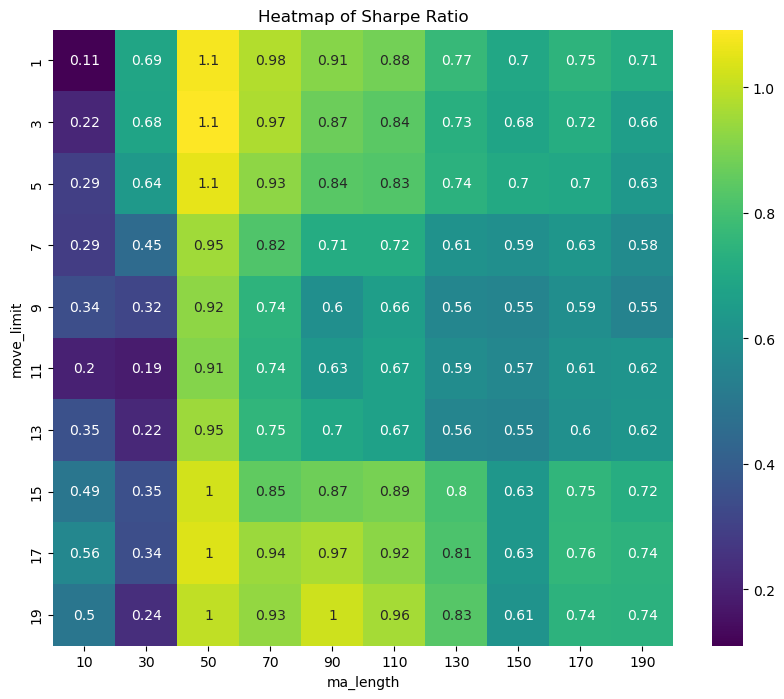

In [206]:
plot_heatmap(results, 'move_limit', 'ma_length', 'Sharpe Ratio')

## 2. Bollinger band + RSI

In [208]:
def bollinger_rsi_strategy(data, rsi_length=14, bb_length=20):
    """
    Apply the Bollinger Band with RSI Strategy on a given DataFrame.
    
    Parameters:
    - data (pd.DataFrame): DataFrame with 'Open', 'High', 'Low', and 'Close' columns.
    - rsi_length (int): Length for RSI calculation.
    - bb_length (int): Length for Bollinger Bands calculation.
    
    Returns:
    - data (pd.DataFrame): DataFrame with strategy results.
    """
    # Define fixed parameters
    bb_stddev = 3.0
    long_tp_pct = 15
    long_sl_pct = 8
    short_tp_pct = 12
    short_sl_pct = 25

    # Calculate RSI
    data['rsi'] = ta.momentum.RSIIndicator(data['Close'], window=rsi_length).rsi()
    
    # Calculate Bollinger Bands
    bb_indicator = ta.volatility.BollingerBands(close=data['Close'], window=bb_length, window_dev=bb_stddev)
    data['bb_upper'] = bb_indicator.bollinger_hband()
    data['bb_lower'] = bb_indicator.bollinger_lband()
    data['bb_middle'] = bb_indicator.bollinger_mavg()
    
    # Calculate take profit and stop loss levels
    data['long_tp_level'] = data['Close'] * (1 + long_tp_pct / 100)
    data['long_sl_level'] = data['Close'] * (1 - long_sl_pct / 100)
    data['short_tp_level'] = data['Close'] * (1 - short_tp_pct / 100)
    data['short_sl_level'] = data['Close'] * (1 + short_sl_pct / 100)
    
    # Entry and Exit Signals
    data['entry_long'] = (data['rsi'] < 30) & (data['Close'] < data['bb_lower']) 
    data['exit_long'] = (data['rsi'] > 70) | (data['Close'] > data['bb_middle'])  
    
    data['entry_short'] = (data['rsi'] > 70) & (data['Close'] > data['bb_upper'])  
    data['exit_short'] = (data['rsi'] < 30) | (data['Close'] < data['bb_middle'])  
    
    # Initialize Positions and Trades
    data['Position (Long Short)'] = 0
    data['In Trade'] = False
    
    for i in range(1, len(data)):
        if not data['In Trade'].iloc[i-1]:
            if data['entry_long'].iloc[i]:
                data.at[data.index[i], 'Position (Long Short)'] = 1
                data.at[data.index[i], 'In Trade'] = 'Long'
                entry_price = data['Close'].iloc[i]
                tp_level = entry_price * (1 + long_tp_pct / 100)
                sl_level = entry_price * (1 - long_sl_pct / 100)
            elif data['entry_short'].iloc[i]:
                data.at[data.index[i], 'Position (Long Short)'] = -1
                data.at[data.index[i], 'In Trade'] = 'Short'
                entry_price = data['Close'].iloc[i]
                tp_level = entry_price * (1 - short_tp_pct / 100)
                sl_level = entry_price * (1 + short_sl_pct / 100)
        elif data['In Trade'].iloc[i-1] == 'Long':
            if data['Close'].iloc[i] >= tp_level or data['Close'].iloc[i] <= sl_level or data['exit_long'].iloc[i]:
                data.at[data.index[i], 'Position (Long Short)'] = 0
                data.at[data.index[i], 'In Trade'] = False
            else:
                data.at[data.index[i], 'Position (Long Short)'] = 1
        elif data['In Trade'].iloc[i-1] == 'Short':
            if data['Close'].iloc[i] <= tp_level or data['Close'].iloc[i] >= sl_level or data['exit_short'].iloc[i]:
                data.at[data.index[i], 'Position (Long Short)'] = 0
                data.at[data.index[i], 'In Trade'] = False
            else:
                data.at[data.index[i], 'Position (Long Short)'] = -1
    
    data['Position (Long Short)'] = data['Position (Long Short)'].replace(0, pd.NA).ffill().fillna(0)
    
    # Define trading fees
    taker_fee = 0.00055  # 0.055%

    # Calculate strategy returns with fees
    data['PnL (Long Short)'] = data['Position (Long Short)'].shift(1) * (data['Close'] / data['Close'].shift(1) - 1)
    data['PnL (Long Short) with Fees'] = data['PnL (Long Short)'] - (abs(data['Position (Long Short)'].shift(1) - data['Position (Long Short)']) * taker_fee)

    # Calculate cumulative returns
    data['Cumulative PnL (Long Short)'] = data['PnL (Long Short) with Fees'].cumsum()
    
    # Calculate drawdown
    data['Cumulative Max'] = data['Cumulative PnL (Long Short)'].cummax()
    data['Drawdown (Long Short)'] = data['Cumulative Max'] - data['Cumulative PnL (Long Short)']
    
    # Calculate Number of Trades
    data['Trade Entry'] = (data['Position (Long Short)'] != 0) & (data['Position (Long Short)'] != data['Position (Long Short)'].shift(1))
    data['Number of Trades'] = data['Trade Entry'].cumsum()
    
    return data


In [209]:
# Usage
bollinger_result = bollinger_rsi_strategy(data)

# Calculate the performance metrics
metrics = performance_metrics(bollinger_result,timeframe)
print(metrics)

{'Sharpe Ratio': -1.2279110933554518, 'Average Return': -77.02497507821082, 'Maximum Drawdown': 364.5223114410529, 'Calmar Ratio': -0.21130386991597513, 'Number of Trades': 147}


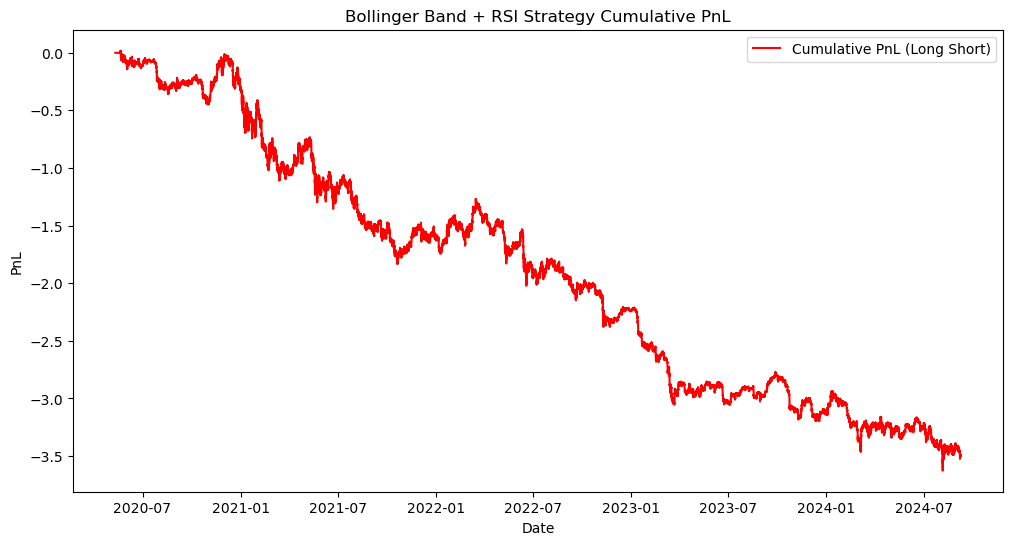

In [210]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(bollinger_result['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Bollinger Band + RSI Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

In [211]:
# Define the search space for Bayesian optimization (Bollinger RSI strategy)
space  = [Integer(5, 101, name='rsi_length'),
          Integer(10, 101, name='bb_length')
         ]

# Define the objective function to minimize (negative Sharpe Ratio)
@use_named_args(space)
def objective(**params):
    result = bollinger_rsi_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    if np.isnan(metrics['Sharpe Ratio']):
        return 0
    return -metrics['Sharpe Ratio']

# Perform Bayesian optimization
res = gp_minimize(objective, space, n_calls=50, random_state=0)

# Get the best parameters and the corresponding metrics
bollinger_best_params = {dim.name: res.x[i] for i, dim in enumerate(space)}
bollinger_best_result = bollinger_rsi_strategy(data, **bollinger_best_params)
bollinger_best_metrics = performance_metrics(bollinger_best_result,timeframe)

print("Best Parameters:", bollinger_best_params)
print("Best Metrics:", bollinger_best_metrics)

Best Parameters: {'rsi_length': 101, 'bb_length': 29}
Best Metrics: {'Sharpe Ratio': 0.33670918763834934, 'Average Return': 9.98807091157666, 'Maximum Drawdown': 62.05704545990499, 'Calmar Ratio': 0.16094982991141504, 'Number of Trades': 2}


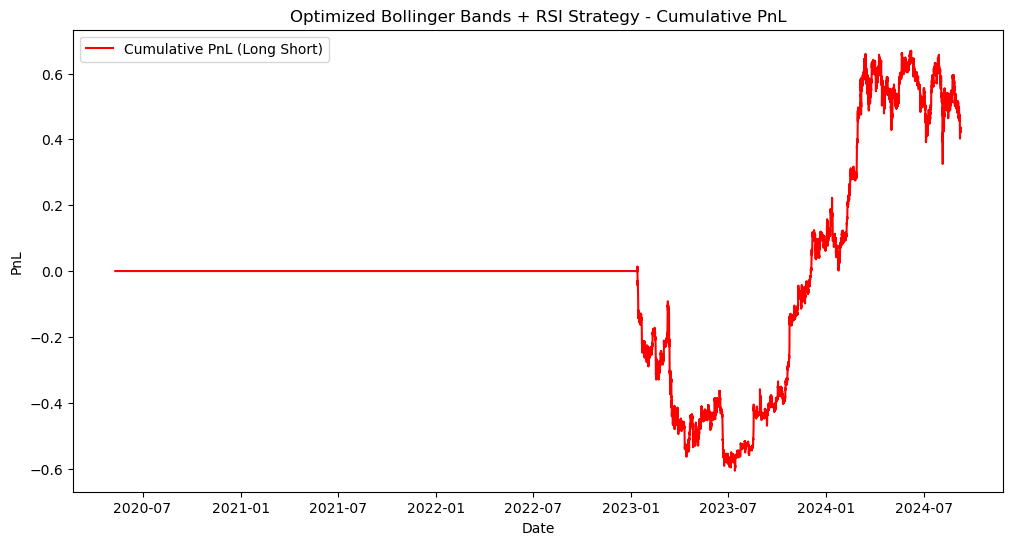

In [212]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(bollinger_best_result['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Optimized Bollinger Bands + RSI Strategy - Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

In [213]:
# Extract the evaluated points and corresponding negative Sharpe Ratios
x_vals = [point[0] for point in res.x_iters]
y_vals = [point[1] for point in res.x_iters]
z_vals = res.func_vals

# Convert negative Sharpe Ratios to positive for visualization
sharpe_ratios = [-z for z in z_vals]

# Find the highest Sharpe Ratio and its corresponding parameters
max_sharpe_ratio = max(sharpe_ratios)
max_index = sharpe_ratios.index(max_sharpe_ratio)
best_rsi_length = x_vals[max_index]
best_bb_length = y_vals[max_index]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_vals,
    y=y_vals,
    z=sharpe_ratios,
    mode='markers',
    marker=dict(
        size=5,
        color=sharpe_ratios,  
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Sharpe Ratio')
    ),
    text=[f'RSI Length: {x}, BB Length: {y}, Sharpe Ratio: {z:.4f}' for x, y, z in zip(x_vals, y_vals, sharpe_ratios)],  # Hover text
    hoverinfo='text'
)])

# Highlight the highest Sharpe Ratio point
fig.add_trace(go.Scatter3d(
    x=[best_rsi_length],
    y=[best_bb_length],
    z=[max_sharpe_ratio],
    mode='markers+text',
    marker=dict(
        size=10,
        color='red'
    ),
    text=[f'Max Sharpe Ratio: {max_sharpe_ratio:.4f}'],
    textposition='top center'
))

# Set labels and title
fig.update_layout(
    scene=dict(
        xaxis_title='RSI Length',
        yaxis_title='BB Length',
        zaxis_title='Sharpe Ratio'
    ),
    title='3D Visualization of Bayesian Optimization for Bollinger RSI Strategy',
    autosize=True
)

fig.show()

## Permutation Testing(Grid Search CV)

In [215]:
# Define parameter grid for Grid Search
param_grid = {
    'rsi_length': list(range(10, 101, 5)), 
    'bb_length': list(np.arange(10, 101, 5))  
}

# Run Grid Search
results = []
for params in ParameterGrid(param_grid):
    result = bollinger_rsi_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    sharpe_ratio = metrics['Sharpe Ratio']
    if not np.isnan(sharpe_ratio):
        results.append((params, sharpe_ratio))
    else:
        print(f"Skipping params {params} due to NaN Sharpe Ratio")


Skipping params {'bb_length': 10, 'rsi_length': 10} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 15} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 20} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 25} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 30} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 35} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 40} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 45} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 50} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 55} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 60} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 65} due to NaN Sharpe Ratio
Skipping params {'bb_length': 10, 'rsi_length': 70} due to NaN Sharpe Ratio
Skipping par

In [216]:
# Ensure results were populated
if not results:
    print("No valid results found. Check strategy implementation and data.")
else:
    # Extract parameter values and Sharpe Ratios
    x_vals = [params['rsi_length'] for params, _ in results]
    y_vals = [params['bb_length'] for params, _ in results]
    z_vals = [sharpe for _, sharpe in results]

    # Create grid for surface plot
    x_grid, y_grid = np.meshgrid(np.unique(x_vals), np.unique(y_vals))
    z_grid = np.zeros_like(x_grid, dtype=float)

    # Populate the z values based on the unique x and y values
    for i, x in enumerate(np.unique(x_vals)):
        for j, y in enumerate(np.unique(y_vals)):
            sharpe_values = [z for (xi, yi), z in zip(zip(x_vals, y_vals), z_vals) if xi == x and yi == y]
            if sharpe_values:
                z_grid[j, i] = max(sharpe_values)

    # Find the highest Sharpe Ratio
    max_sharpe_idx = np.unravel_index(np.argmax(z_grid, axis=None), z_grid.shape)
    max_sharpe_value = z_grid[max_sharpe_idx]
    best_rsi_length = x_grid[max_sharpe_idx]
    best_bb_length = y_grid[max_sharpe_idx]

    # Plotly 3D surface plot
    fig = go.Figure(data=[go.Surface(x=x_grid, y=y_grid, z=z_grid, colorscale='Viridis')])

    # Add a scatter point for the maximum Sharpe Ratio
    fig.add_trace(go.Scatter3d(
        x=[best_rsi_length],
        y=[best_bb_length],
        z=[max_sharpe_value],
        mode='markers+text',
        marker=dict(size=5, color='red'),
        text=[f'Max Sharpe Ratio: {max_sharpe_value:.4f}'],
        textposition='top center'
    ))

    fig.update_layout(title='3D Surface Plot for Bollinger Band + RSI Strategy (Grid Search CV)', scene=dict(
        xaxis_title='RSI Length',
        yaxis_title='BB Length',
        zaxis_title='Sharpe Ratio'
    ))
    fig.show()

    # Print the best parameters and metrics
    print("Best Parameters:", {"rsi_length": best_rsi_length, "bb_length": best_bb_length})
    print("Best Sharpe Ratio:", max_sharpe_value)
    best_result = bollinger_rsi_strategy(data.copy(), rsi_length=best_rsi_length, bb_length=best_bb_length)
    best_metrics = performance_metrics(best_result,timeframe)
    print("Average Return:", best_metrics.get('Average Return', 'N/A'))
    print("Maximum Drawdown:", best_metrics.get('Maximum Drawdown', 'N/A'))
    print("Calmar Ratio:", best_metrics.get('Calmar Ratio', 'N/A'))
    print("Number of Trades:", best_metrics.get('Number of Trades', 'N/A'))

Best Parameters: {'rsi_length': 100, 'bb_length': 15}
Best Sharpe Ratio: 0.33670918763834934
Average Return: 9.98807091157666
Maximum Drawdown: 62.05704545990499
Calmar Ratio: 0.16094982991141504
Number of Trades: 2


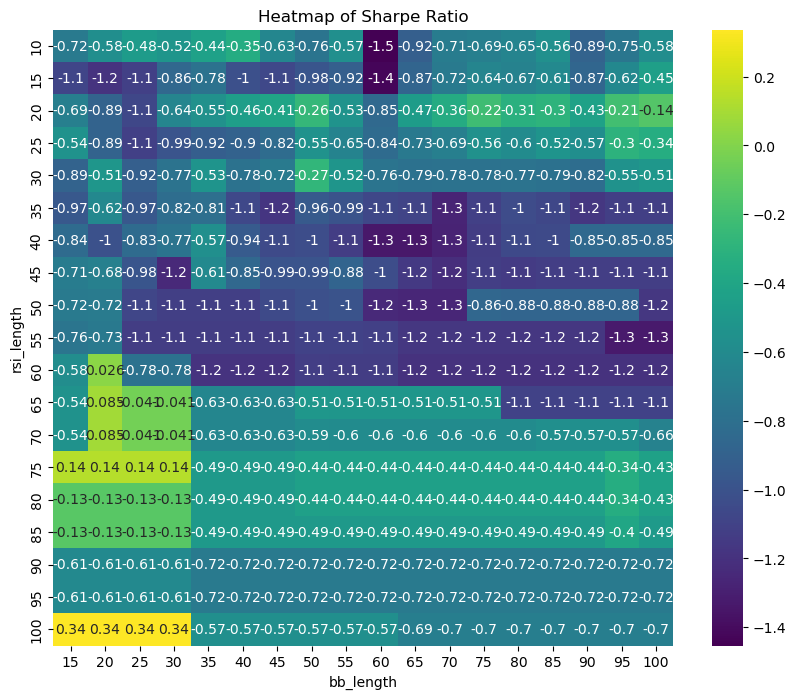

In [217]:
plot_heatmap(results, 'rsi_length', 'bb_length', 'Sharpe Ratio')

## 3. Z_score_sma_strategy

In [219]:
def z_score_sma_strategy(data, sma_length=50, z_score_threshold=0.75):
    """
    Apply the Z-Score SMA strategy on a given DataFrame.
    
    Parameters:
    - data (pd.DataFrame): DataFrame with a 'Close' price column.
    - sma_length (int): Simple moving average window length.
    - z_score_threshold (float): Z-score threshold for signal generation.
    
    Returns:
    - data (pd.DataFrame): DataFrame with strategy columns and cumulative returns.
    """
    # Calculate the SMA
    data['sma'] = ta.trend.SMAIndicator(close=data['Close'], window=sma_length).sma_indicator()
    
    # Calculate the Z-Score
    data['mean'] = data['Close'].rolling(window=sma_length).mean()
    data['std'] = data['Close'].rolling(window=sma_length).std()
    data['z_score'] = (data['Close'] - data['sma']) / data['std']
    
    # Generate trading signals
    data['long_signal'] = (data['z_score'] > z_score_threshold)
    data['short_signal'] = (data['z_score'] < -z_score_threshold)
    
    # Initialize positions
    data['Position (Long Short)'] = 0
    data.loc[data['long_signal'], 'Position (Long Short)'] = 1
    data.loc[data['short_signal'], 'Position (Long Short)'] = -1
    
    # Forward fill positions
    data['Position (Long Short)'] = data['Position (Long Short)'].replace(0, np.nan).ffill().fillna(0)
    
    # Define trading fees
    taker_fee = 0.00055  # 0.055%

    # Calculate strategy returns with fees
    data['PnL (Long Short)'] = data['Position (Long Short)'].shift(1) * data['Close'].pct_change()
    data['PnL (Long Short) with Fees'] = data['PnL (Long Short)'] - (abs(data['Position (Long Short)'].shift(1) - data['Position (Long Short)']) * taker_fee)

    # Calculate cumulative returns
    data['Cumulative PnL (Long Short)'] = data['PnL (Long Short) with Fees'].cumsum()
    
    # Calculate drawdown
    data['Cumulative Max'] = data['Cumulative PnL (Long Short)'].cummax()
    data['Drawdown (Long Short)'] = data['Cumulative Max'] - data['Cumulative PnL (Long Short)']
    
    # Calculate number of trades
    data['Trade Entry'] = (data['Position (Long Short)'] != 0) & (data['Position (Long Short)'] != data['Position (Long Short)'].shift(1))
    data['Number of Trades'] = data['Trade Entry'].cumsum()
    
    return data


In [220]:
zscore_result = z_score_sma_strategy(data)

# Calculate the performance metrics
metrics = performance_metrics(zscore_result,timeframe)
print(metrics)

{'Sharpe Ratio': 0.49071183972732474, 'Average Return': 30.86689185715903, 'Maximum Drawdown': 102.25790709106026, 'Calmar Ratio': 0.3018533503690055, 'Number of Trades': 930}


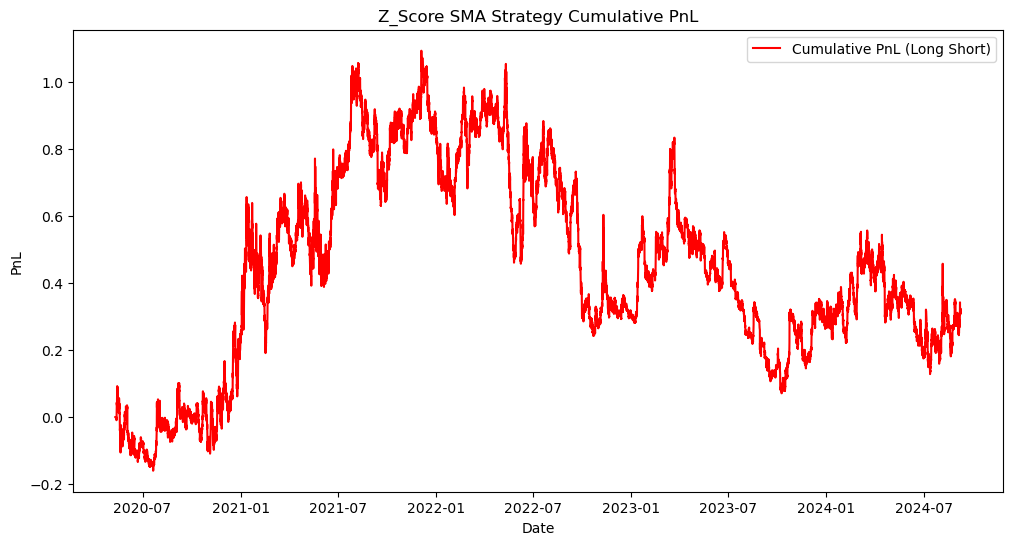

In [221]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(zscore_result['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Z_Score SMA Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

In [222]:
# Define the search space for Bayesian optimization (Z-Score SMA strategy)
space = [
    Integer(10, 201, name='sma_length'),  
    Real(0.1, 3.1, name='z_score_threshold')  
]

# Define the objective function to minimize (negative Sharpe Ratio)
@use_named_args(space)
def objective(**params):
    # Apply the Z-Score SMA strategy with the given parameters
    result = z_score_sma_strategy(data.copy(), **params)
    # Calculate performance metrics 
    metrics = performance_metrics(result,timeframe)
    # Return the negative Sharpe Ratio for minimization (maximize Sharpe Ratio)
    if np.isnan(metrics['Sharpe Ratio']):
        return 0
    return -metrics['Sharpe Ratio']

# Perform Bayesian optimization
res = gp_minimize(objective, space, n_calls=50, random_state=0)

# Get the best parameters and the corresponding metrics
zscore_best_params = {dim.name: res.x[i] for i, dim in enumerate(space)}
zscore_best_result = z_score_sma_strategy(data, **zscore_best_params)
zscore_best_metrics = performance_metrics(zscore_best_result,timeframe)

print("Best Parameters:", zscore_best_params)
print("Best Metrics:", zscore_best_metrics)

Best Parameters: {'sma_length': 71, 'z_score_threshold': 2.461431977868311}
Best Metrics: {'Sharpe Ratio': 1.2270343280355274, 'Average Return': 77.16337657966054, 'Maximum Drawdown': 67.47764108445958, 'Calmar Ratio': 1.1435399243295663, 'Number of Trades': 206}


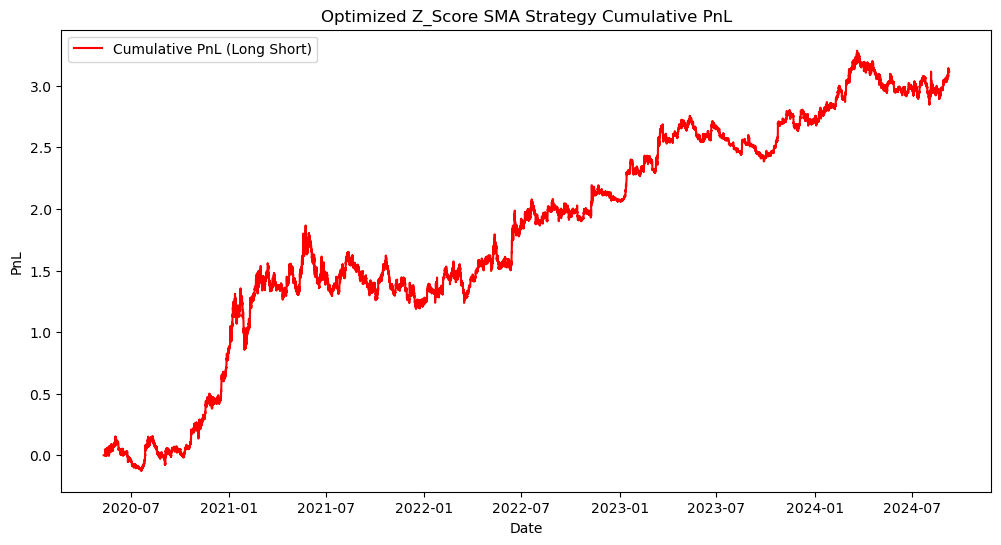

In [223]:
# Plotting the optimized equity curve
plt.figure(figsize=(12, 6))
plt.plot(zscore_best_result['Cumulative PnL (Long Short)'], label='Cumulative PnL (Long Short)', color='red')
plt.title('Optimized Z_Score SMA Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.legend()
plt.show()

In [224]:
# Extract the evaluated points and corresponding negative Sharpe Ratios
x_vals = [point[0] for point in res.x_iters]
y_vals = [point[1] for point in res.x_iters]
z_vals = res.func_vals

# Convert negative Sharpe Ratios to positive for visualization
sharpe_ratios = [-z for z in z_vals]

# Find the highest Sharpe Ratio and its corresponding parameters
max_sharpe_ratio = max(sharpe_ratios)
max_index = sharpe_ratios.index(max_sharpe_ratio)
best_sma_length = x_vals[max_index]
best_z_score_threshold = y_vals[max_index]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_vals,
    y=y_vals,
    z=sharpe_ratios,
    mode='markers',
    marker=dict(
        size=5,
        color=sharpe_ratios,  
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Sharpe Ratio')
    ),
    text=[f'SMA Length: {x}, Z-Score Threshold: {y}, Sharpe Ratio: {z:.4f}' for x, y, z in zip(x_vals, y_vals, sharpe_ratios)],  # Hover text
    hoverinfo='text'
)])

# Highlight the highest Sharpe Ratio point
fig.add_trace(go.Scatter3d(
    x=[best_sma_length],
    y=[best_z_score_threshold],
    z=[max_sharpe_ratio],
    mode='markers+text',
    marker=dict(
        size=10,
        color='red'
    ),
    text=[f'Max Sharpe Ratio: {max_sharpe_ratio:.4f}'],
    textposition='top center'
))

# Set labels and title
fig.update_layout(
    scene=dict(
        xaxis_title='SMA Length',
        yaxis_title='Z-Score Threshold',
        zaxis_title='Sharpe Ratio'
    ),
    title='3D Visualization of Bayesian Optimization for Z-Score SMA Strategy',
    autosize=True
)

fig.show()


## Permutation Testing(Grid Search CV)

In [226]:
# Define parameter grid for Grid Search
param_grid = {
    'sma_length': list(range(10, 201, 10)),  
    'z_score_threshold': list(np.arange(0.1, 3.1, 0.1))  
}

# Placeholder for storing results
results = []

# Run Grid Search
for params in ParameterGrid(param_grid):
    result = z_score_sma_strategy(data.copy(), **params)
    metrics = performance_metrics(result,timeframe)
    sharpe_ratio = metrics['Sharpe Ratio']
    if not np.isnan(sharpe_ratio):
        results.append((params, sharpe_ratio))
    else:
        print(f"Skipping params {params} due to NaN Sharpe Ratio")

# Extract the best parameters based on the highest Sharpe Ratio
best_params, best_sharpe_ratio = max(results, key=lambda x: x[1])

print("Best Parameters:", best_params)
print("Best Sharpe Ratio:", best_sharpe_ratio)

Skipping params {'sma_length': 10, 'z_score_threshold': 2.9000000000000004} due to NaN Sharpe Ratio
Skipping params {'sma_length': 10, 'z_score_threshold': 3.0000000000000004} due to NaN Sharpe Ratio
Best Parameters: {'sma_length': 60, 'z_score_threshold': 3.0000000000000004}
Best Sharpe Ratio: 1.4061146863520488


In [227]:
# Ensure results were populated
if not results:
    print("No valid results found. Check strategy implementation and data.")
else:
    # Extract parameter values and Sharpe Ratios
    x_vals = [params['sma_length'] for params, _ in results]
    y_vals = [params['z_score_threshold'] for params, _ in results]
    z_vals = [sharpe for _, sharpe in results]

    # Create grid for surface plot
    x_grid, y_grid = np.meshgrid(np.unique(x_vals), np.unique(y_vals))
    z_grid = np.zeros_like(x_grid, dtype=float)

    # Populate the z values based on the unique x and y values
    for i, x in enumerate(np.unique(x_vals)):
        for j, y in enumerate(np.unique(y_vals)):
            sharpe_values = [z for (xi, yi), z in zip(zip(x_vals, y_vals), z_vals) if xi == x and yi == y]
            if sharpe_values:
                z_grid[j, i] = max(sharpe_values)

    # Find the highest Sharpe Ratio
    max_sharpe_idx = np.unravel_index(np.argmax(z_grid, axis=None), z_grid.shape)
    max_sharpe_value = z_grid[max_sharpe_idx]
    best_sma_length = x_grid[max_sharpe_idx]
    best_z_score_threshold = y_grid[max_sharpe_idx]

    # Plotly 3D surface plot
    fig = go.Figure(data=[go.Surface(x=x_grid, y=y_grid, z=z_grid, colorscale='Viridis')])

    # Add a scatter point for the maximum Sharpe Ratio
    fig.add_trace(go.Scatter3d(
        x=[best_sma_length],
        y=[best_z_score_threshold],
        z=[max_sharpe_value],
        mode='markers+text',
        marker=dict(size=5, color='red'),
        text=[f'Max Sharpe Ratio: {max_sharpe_value:.4f}'],
        textposition='top center'
    ))

    fig.update_layout(title='3D Surface Plot for Z-Score SMA Strategy (Grid Search CV)', scene=dict(
        xaxis_title='SMA Length',
        yaxis_title='Z-Score Threshold',
        zaxis_title='Sharpe Ratio'
    ))
    fig.show()

    # Print the best parameters and metrics
    print("Best Parameters:", {"sma_length": best_sma_length, "z_score_threshold": best_z_score_threshold})
    print("Best Sharpe Ratio:", max_sharpe_value)
    best_result = z_score_sma_strategy(data.copy(), sma_length=best_sma_length, z_score_threshold=best_z_score_threshold)
    best_metrics = performance_metrics(best_result,timeframe)
    print("Average Return:", best_metrics.get('Average Return', 'N/A'))
    print("Maximum Drawdown:", best_metrics.get('Maximum Drawdown', 'N/A'))
    print("Calmar Ratio:", best_metrics.get('Calmar Ratio', 'N/A'))
    print("Number of Trades:", best_metrics.get('Number of Trades', 'N/A'))


Best Parameters: {'sma_length': 60, 'z_score_threshold': 3.0000000000000004}
Best Sharpe Ratio: 1.4061146863520488
Average Return: 88.296097371217
Maximum Drawdown: 58.01399828910853
Calmar Ratio: 1.5219791770117246
Number of Trades: 144


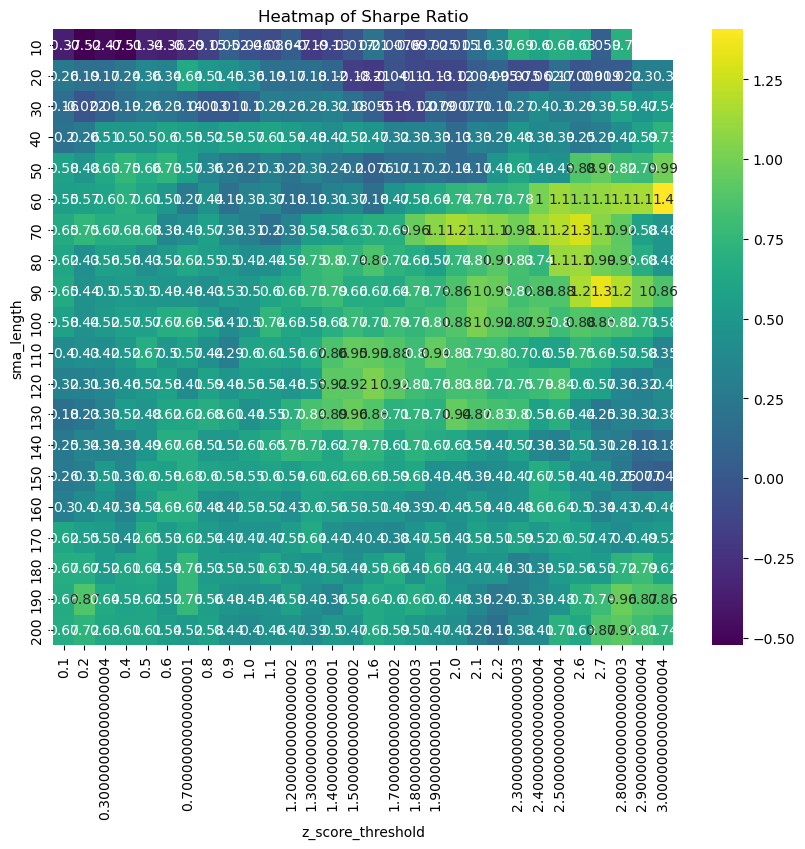

In [228]:
plot_heatmap(results, 'sma_length', 'z_score_threshold', 'Sharpe Ratio')